# Alzheimer's Disease Stage Classification from Brain MRI Images

Classification of Alzheimer's disease stages from MRI brain scans using deep learning.  
Four classes: **NonDemented**, **VeryMildDemented**, **MildDemented**, **ModerateDemented**.

## 1. Imports and Setup

The notebook runs unchanged in the local project environment and in Google Colab. Colab uses its CUDA-enabled PyTorch installation, mounts Google Drive for persistent ResNet-50 search checkpoints, and automatically enables mixed-precision training when a GPU is active.

In [3]:
import copy
import importlib.util
import random
import shutil
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_recall_fscore_support
)
from tqdm.notebook import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 1337


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Favor repeatable results over maximum cuDNN performance.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

IN_COLAB = importlib.util.find_spec('google.colab') is not None
COLAB_PROJECT_DIR = Path('/content/drive/MyDrive/alzheimer-classification')
COLAB_MODEL_DIR = COLAB_PROJECT_DIR / 'models'

if IN_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    COLAB_MODEL_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = device.type == 'cuda'

if IN_COLAB and device.type != 'cuda':
    raise RuntimeError(
        'No GPU is active. In Colab, select Runtime > Change runtime type > GPU.'
    )
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"Mixed precision: {USE_AMP}")
print(f"Running in Colab: {IN_COLAB}")
print(f"PyTorch version: {torch.__version__}")
print(f"Random seed: {RANDOM_STATE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
GPU memory: 14.6 GB
Mixed precision: True
Running in Colab: True
PyTorch version: 2.11.0+cu128
Random seed: 1337


## 2. Helper Functions

In [4]:
def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def bind_gpu(data):
    dev = get_device()
    if isinstance(data, (list, tuple)):
        return [bind_gpu(item) for item in data]
    return data.to(dev, non_blocking=True)


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    for name, layer in model.named_children():
        n = sum(p.numel() for p in layer.parameters())
        print(f"Layer: {name}, Parameters: {n}")
    print(f"Total parameters: {total}")
    return total


def state_dict_to_cpu(model):
    return {
        name: parameter.detach().cpu().clone()
        for name, parameter in model.state_dict().items()
    }


def train_model(
    model,
    criterion,
    optimizer,
    num_epochs,
    train_loader,
    val_loader,
    patience=5,
    model_name='Model',
    selection_metric='val_loss',
    use_amp=None,
):
    metrics = {
        'epoch': [],
        'train_loss': [], 'train_accuracy': [],
        'val_loss': [], 'val_accuracy': [], 'val_macro_f1': [],
        'epoch_seconds': [],
    }

    dev = get_device()
    use_amp = dev.type == 'cuda' if use_amp is None else use_amp
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    best_state = state_dict_to_cpu(model)
    best_macro_f1 = -1.0
    best_val_loss = float('inf')
    best_val_accuracy = 0.0
    best_epoch = 0
    epochs_without_improvement = 0

    pbar = tqdm(range(1, num_epochs + 1), desc=f'{model_name} progress')
    for epoch in pbar:
        epoch_started_at = time.perf_counter()
        pbar.set_description(f'{model_name} | Epoch {epoch}/{num_epochs}')
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_batches = tqdm(
            train_loader,
            desc=f'Training epoch {epoch}/{num_epochs}',
            leave=False
        )
        for inputs, labels in train_batches:
            inputs, labels = bind_gpu((inputs, labels))

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=dev.type, enabled=use_amp):
                probabilities, logits = model(inputs)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.size(0)
            train_loss += loss.item() * batch_size
            train_correct += (torch.argmax(probabilities, dim=1) == labels).sum().item()
            train_total += batch_size
            train_batches.set_postfix({'batch_loss': f'{loss.item():.4f}'})

        train_loss /= train_total
        train_accuracy = train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_total = 0
        val_predictions = []
        val_targets = []

        with torch.no_grad():
            validation_batches = tqdm(
                val_loader,
                desc=f'Validation epoch {epoch}/{num_epochs}',
                leave=False
            )
            for inputs, labels in validation_batches:
                inputs, labels = bind_gpu((inputs, labels))
                with torch.autocast(device_type=dev.type, enabled=use_amp):
                    probabilities, logits = model(inputs)
                    loss = criterion(logits, labels)

                batch_size = labels.size(0)
                val_loss += loss.item() * batch_size
                val_total += batch_size
                val_predictions.extend(probabilities.argmax(dim=1).cpu().tolist())
                val_targets.extend(labels.cpu().tolist())

        val_loss /= val_total
        val_accuracy = accuracy_score(val_targets, val_predictions)
        _, _, val_macro_f1, _ = precision_recall_fscore_support(
            val_targets,
            val_predictions,
            labels=range(len(CLASS_NAMES)),
            average='macro',
            zero_division=0,
        )

        metrics['epoch'].append(epoch)
        metrics['train_loss'].append(train_loss)
        metrics['train_accuracy'].append(train_accuracy)
        metrics['val_loss'].append(val_loss)
        metrics['val_accuracy'].append(val_accuracy)
        metrics['val_macro_f1'].append(val_macro_f1)
        metrics['epoch_seconds'].append(time.perf_counter() - epoch_started_at)

        if selection_metric == 'val_macro_f1':
            improved = (
                val_macro_f1 > best_macro_f1 + 1e-12
                or (
                    abs(val_macro_f1 - best_macro_f1) <= 1e-12
                    and val_loss < best_val_loss
                )
            )
        elif selection_metric == 'val_loss':
            improved = val_loss < best_val_loss
        else:
            raise ValueError(f'Unsupported selection metric: {selection_metric}')

        if improved:
            best_state = state_dict_to_cpu(model)
            best_macro_f1 = val_macro_f1
            best_val_loss = val_loss
            best_val_accuracy = val_accuracy
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        pbar.set_postfix({
            'train_loss': f'{train_loss:.4f}',
            'val_loss': f'{val_loss:.4f}',
            'val_acc': f'{val_accuracy:.4f}',
            'val_macro_f1': f'{val_macro_f1:.4f}',
            'epoch_min': f"{metrics['epoch_seconds'][-1] / 60:.1f}",
        })

        if epochs_without_improvement >= patience:
            print(f"Early stopping after epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    selection = {
        'best_epoch': best_epoch,
        'val_macro_f1': best_macro_f1,
        'val_loss': best_val_loss,
        'val_accuracy': best_val_accuracy,
    }
    print(
        f'Best epoch: {best_epoch} | validation loss: {best_val_loss:.4f} | '
        f'validation macro F1: {best_macro_f1:.4f}'
    )
    return metrics, selection


def plot_training_metrics(metrics, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13)

    axes[0].plot(metrics['epoch'], metrics['train_loss'], label='Train Loss')
    axes[0].plot(metrics['epoch'], metrics['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(metrics['epoch'], metrics['train_accuracy'], label='Train Accuracy')
    axes[1].plot(metrics['epoch'], metrics['val_accuracy'], label='Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


CLASS_NAMES = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']


def evaluate_model(model, criterion, dataloader, title='', use_amp=None):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    predicted_labels = []
    true_labels = []
    dev = get_device()
    use_amp = dev.type == 'cuda' if use_amp is None else use_amp

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = bind_gpu((inputs, labels))
            with torch.autocast(device_type=dev.type, enabled=use_amp):
                probabilities, logits = model(inputs)
                loss = criterion(logits, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            predicted = torch.argmax(probabilities, dim=1)
            predicted_labels.extend(predicted.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())

    loss = total_loss / total_samples
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        average='weighted',
        zero_division=0
    )
    _, per_class_recall, per_class_f1, support = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=range(len(CLASS_NAMES)),
        average=None,
        zero_division=0
    )
    macro_f1 = per_class_f1.mean()

    print(title)
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall   : {recall:.4f}")
    print(f"Weighted F1       : {f1_score:.4f}")
    print(f"Macro F1          : {macro_f1:.4f}")

    cm = confusion_matrix(
        true_labels,
        predicted_labels,
        labels=range(len(CLASS_NAMES))
    )
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    return {
        'loss': loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'macro_f1': macro_f1,
        'per_class_recall': dict(zip(CLASS_NAMES, per_class_recall)),
        'per_class_f1': dict(zip(CLASS_NAMES, per_class_f1)),
        'support': dict(zip(CLASS_NAMES, support)),
        'true_labels': true_labels,
        'predicted_labels': predicted_labels,
    }


def compare_model_results(model_results, title):
    comparison = pd.DataFrame({
        model_name: {
            'Test Loss': results['loss'],
            'Accuracy': results['accuracy'],
            'Weighted Precision': results['precision'],
            'Weighted Recall': results['recall'],
            'Weighted F1': results['f1_score'],
            'Macro F1': results['macro_f1'],
        }
        for model_name, results in model_results.items()
    }).T
    comparison.index.name = 'Model'
    display(comparison.round(4))

    comparison[[
        'Accuracy',
        'Weighted Precision',
        'Weighted Recall',
        'Weighted F1',
        'Macro F1',
    ]].plot(kind='bar', figsize=(11, 5), ylim=(0, 1))
    plt.title(f'{title} - Overall Metrics')
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.xticks(rotation=10, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.tight_layout(rect=(0, 0, 0.78, 1))
    plt.show()

    per_class_recall = pd.DataFrame({
        model_name: results['per_class_recall']
        for model_name, results in model_results.items()
    })
    per_class_recall.index.name = 'Class'
    print('Per-Class Test Recall')
    display(per_class_recall.round(4))

    per_class_recall.plot(kind='bar', figsize=(11, 5), ylim=(0, 1))
    plt.title(f'{title} - Per-Class Recall')
    plt.xlabel('Class')
    plt.ylabel('Recall')
    plt.xticks(rotation=20, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.tight_layout(rect=(0, 0, 0.78, 1))
    plt.show()

    return comparison, per_class_recall


print("Helper functions defined.")

Helper functions defined.


## 3. Data Loading and Exploratory Data Analysis

In [5]:
LOCAL_DATASET_ROOT = Path('Alzheimer_s Dataset')
COLAB_DATASET_CACHE = Path('/content/Alzheimer_s Dataset')
COLAB_DATASET_SOURCE = COLAB_PROJECT_DIR / 'Alzheimer_s Dataset'

if (
    IN_COLAB
    and not LOCAL_DATASET_ROOT.is_dir()
    and not COLAB_DATASET_CACHE.is_dir()
    and COLAB_DATASET_SOURCE.is_dir()
):
    print('Copying the dataset from Google Drive to the Colab runtime...')
    shutil.copytree(COLAB_DATASET_SOURCE, COLAB_DATASET_CACHE)

dataset_candidates = [LOCAL_DATASET_ROOT]
if IN_COLAB:
    dataset_candidates.extend([COLAB_DATASET_CACHE, COLAB_DATASET_SOURCE])
DATASET_ROOT = next(
    (candidate for candidate in dataset_candidates if candidate.is_dir()),
    LOCAL_DATASET_ROOT,
)
KAGGLE_TRAIN_DIR = DATASET_ROOT / 'train'
KAGGLE_TEST_DIR = DATASET_ROOT / 'test'

CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

missing_directories = [
    directory
    for split_dir in (KAGGLE_TRAIN_DIR, KAGGLE_TEST_DIR)
    for directory in [split_dir, *(split_dir / name for name in CLASS_NAMES)]
    if not directory.is_dir()
]
if missing_directories:
    missing = '\n'.join(f'  - {directory}' for directory in missing_directories)
    raise FileNotFoundError(
        'The original Kaggle train/test folders are required. Missing:\n'
        f'{missing}\n\n'
        'Download and extract tourist55/alzheimers-dataset-4-class-of-images '
        'so Alzheimer_s Dataset/train and Alzheimer_s Dataset/test exist.'
    )


def load_split(split_dir):
    paths, split_labels = [], []
    for class_name, class_idx in CLASS_TO_IDX.items():
        for img_path in sorted((split_dir / class_name).glob('*')):
            if img_path.is_file():
                paths.append(img_path)
                split_labels.append(class_idx)
    return paths, split_labels


kaggle_train_paths, kaggle_train_labels = load_split(KAGGLE_TRAIN_DIR)
kaggle_test_paths, kaggle_test_labels = load_split(KAGGLE_TEST_DIR)

EXPECTED_SPLIT_COUNTS = {
    'train': {
        'NonDemented': 2560, 'VeryMildDemented': 1792,
        'MildDemented': 717, 'ModerateDemented': 52,
    },
    'test': {
        'NonDemented': 640, 'VeryMildDemented': 448,
        'MildDemented': 179, 'ModerateDemented': 12,
    },
}
for split_name, split_labels in [
    ('train', kaggle_train_labels),
    ('test', kaggle_test_labels),
]:
    actual = Counter(split_labels)
    expected = EXPECTED_SPLIT_COUNTS[split_name]
    for class_name, class_idx in CLASS_TO_IDX.items():
        if actual[class_idx] != expected[class_name]:
            raise ValueError(
                f'Unexpected {split_name}/{class_name} count: '
                f'{actual[class_idx]} (expected {expected[class_name]}).'
            )

image_paths = kaggle_train_paths + kaggle_test_paths
labels = kaggle_train_labels + kaggle_test_labels

print(f"Dataset root:           {DATASET_ROOT.resolve()}")
print(f"Kaggle training images: {len(kaggle_train_paths)}")
print(f"Kaggle test images:     {len(kaggle_test_paths)}")
print(f"Total images:           {len(image_paths)}")
counts = Counter(labels)
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {counts[idx]}")

Dataset root:           /content/Alzheimer_s Dataset
Kaggle training images: 5121
Kaggle test images:     1279
Total images:           6400
  NonDemented: 3200
  VeryMildDemented: 2240
  MildDemented: 896
  ModerateDemented: 64


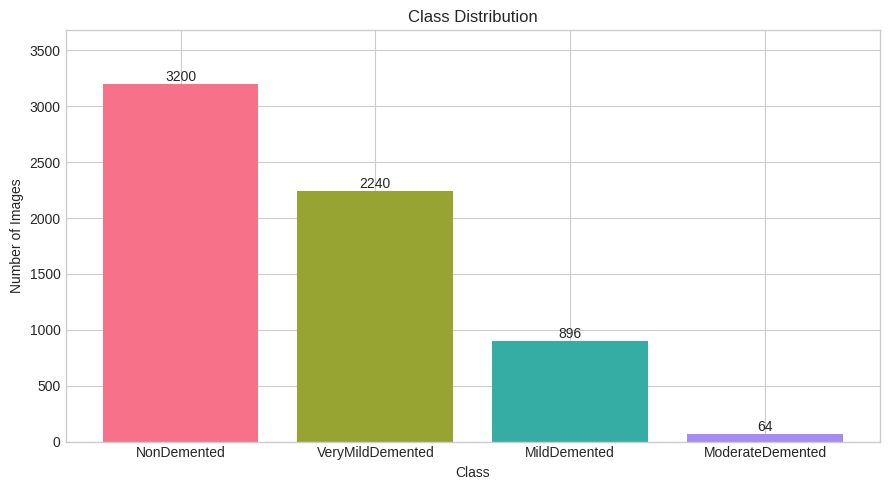

In [6]:
class_counts = [counts[i] for i in range(4)]
colors = sns.color_palette('husl', 4)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(CLASS_NAMES, class_counts, color=colors)

for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(count), ha='center')

ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.set_ylim(0, max(class_counts) * 1.15)
plt.tight_layout()
plt.show()

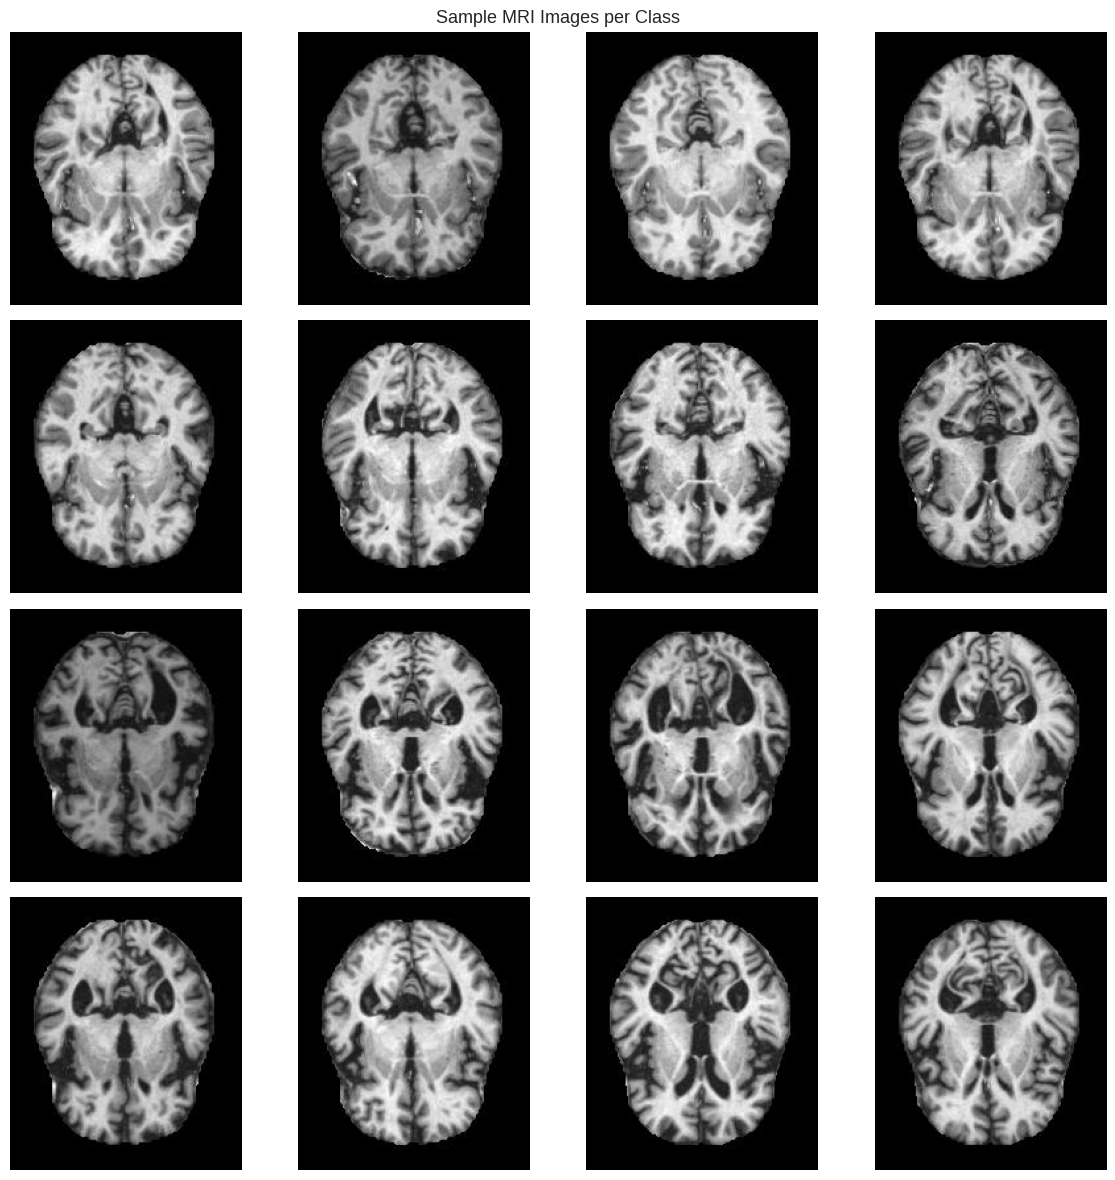

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Sample MRI Images per Class', fontsize=13)

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_paths = [p for p, l in zip(image_paths, labels) if l == class_idx]
    for col, img_path in enumerate(class_paths[:4]):
        ax = axes[class_idx][col]
        ax.imshow(Image.open(img_path).convert('RGB'))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(class_name, fontsize=9, rotation=90, labelpad=10)
            ax.yaxis.set_label_position('left')

plt.tight_layout()
plt.show()

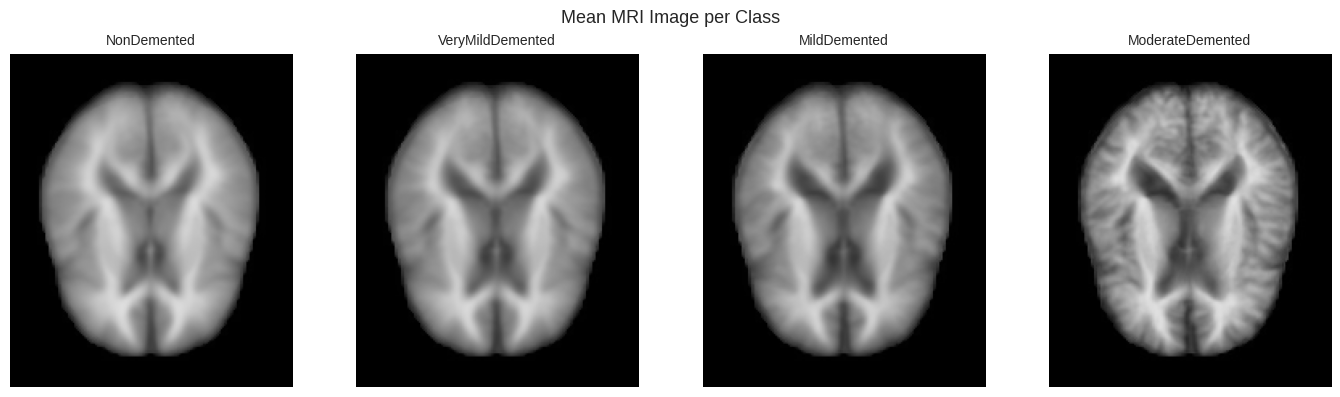

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Mean MRI Image per Class', fontsize=13)

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_paths = [p for p, l in zip(image_paths, labels) if l == class_idx]
    imgs = np.stack([
        np.array(Image.open(p).convert('L').resize((176, 208)), dtype=np.float32)
        for p in class_paths
    ])
    mean_img = imgs.mean(axis=0)
    axes[class_idx].imshow(mean_img, cmap='gray', vmin=0, vmax=255)
    axes[class_idx].set_title(class_name, fontsize=10)
    axes[class_idx].axis('off')

plt.tight_layout()
plt.show()

## 4. Train, Validation and Test Split

The original Kaggle test directory is preserved exactly and is used only for final evaluation. A stratified 20% validation subset is drawn from Kaggle's training directory; no test image participates in training, validation, normalization or augmentation.

In [9]:
all_training_paths = np.array(kaggle_train_paths, dtype=object)
all_training_labels = np.array(kaggle_train_labels, dtype=np.int64)

train_paths, validation_paths, train_labels, validation_labels = train_test_split(
    all_training_paths,
    all_training_labels,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=all_training_labels
)

train_paths, train_labels = list(train_paths), list(train_labels)
validation_paths, validation_labels = list(validation_paths), list(validation_labels)
test_paths, test_labels = list(kaggle_test_paths), list(kaggle_test_labels)

split_path_sets = {
    'training': set(train_paths),
    'validation': set(validation_paths),
    'test': set(test_paths),
}
split_pairs = [('training', 'validation'), ('training', 'test'), ('validation', 'test')]
for first_name, second_name in split_pairs:
    overlap = split_path_sets[first_name] & split_path_sets[second_name]
    if overlap:
        raise ValueError(
            f'{first_name.title()} and {second_name} contain '
            f'{len(overlap)} overlapping file paths.'
        )

if len(train_paths) + len(validation_paths) != len(kaggle_train_paths):
    raise ValueError('Training/validation split does not preserve all Kaggle training images.')

print(f"Training images (80% of Kaggle train):   {len(train_paths)}")
print(f"Validation images (20% of Kaggle train): {len(validation_paths)}")
print(f"Untouched Kaggle test images:            {len(test_paths)}")

Training images (80% of Kaggle train):   4096
Validation images (20% of Kaggle train): 1025
Untouched Kaggle test images:            1279


Split,Training,Validation,Test
Class,,,
NonDemented,2048,512,640
VeryMildDemented,1433,359,448
MildDemented,573,144,179
ModerateDemented,42,10,12


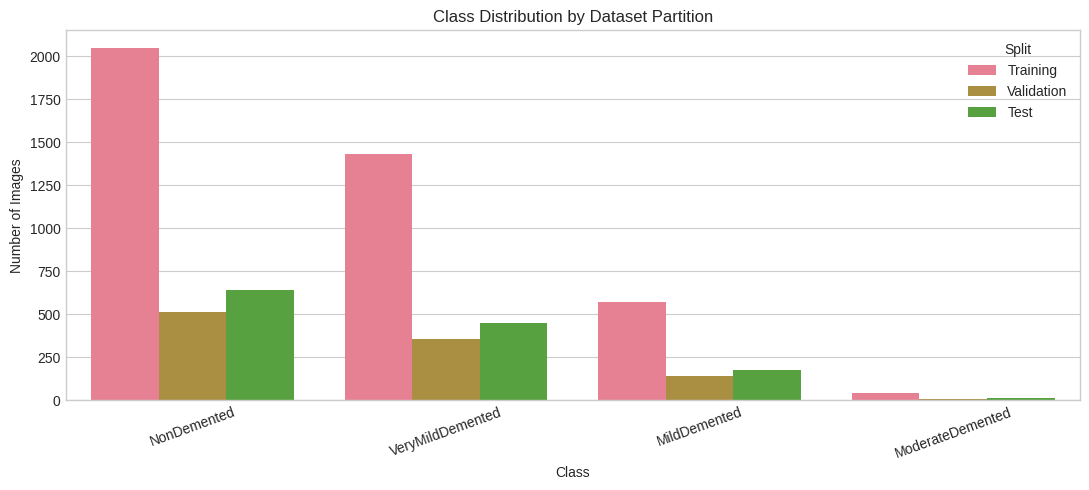

In [10]:
split_records = []
for split_name, split_labels in [
    ('Training', train_labels),
    ('Validation', validation_labels),
    ('Test', test_labels),
]:
    split_counts = Counter(split_labels)
    for class_index, class_name in enumerate(CLASS_NAMES):
        split_records.append({
            'Split': split_name,
            'Class': class_name,
            'Count': split_counts[class_index],
        })

split_distribution = pd.DataFrame(split_records)
split_table = split_distribution.pivot(index='Class', columns='Split', values='Count')
split_table = split_table.loc[CLASS_NAMES, ['Training', 'Validation', 'Test']]
display(split_table)

plt.figure(figsize=(11, 5))
sns.barplot(data=split_distribution, x='Class', y='Count', hue='Split')
plt.title('Class Distribution by Dataset Partition')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Dataset Preparation and Training-Only Augmentation

Normalization statistics are calculated using only the training partition. The first CNN uses the original training images. For the second CNN, additional transformed copies are created dynamically for the MildDemented and ModerateDemented training classes.

No validation or test image is augmented or included in either training dataset.

In [11]:
pixel_sum = 0.0
pixel_squared_sum = 0.0
pixel_count = 0

for img_path in tqdm(train_paths, desc='Calculating normalization statistics'):
    image = Image.open(img_path).convert('L').resize((128, 128))
    pixels = np.asarray(image, dtype=np.float64) / 255.0
    pixel_sum += pixels.sum()
    pixel_squared_sum += np.square(pixels).sum()
    pixel_count += pixels.size

TRAIN_MEAN = pixel_sum / pixel_count
TRAIN_VARIANCE = pixel_squared_sum / pixel_count - TRAIN_MEAN ** 2
TRAIN_STD = np.sqrt(max(TRAIN_VARIANCE, 1e-12))

print(f"Training mean: {TRAIN_MEAN:.6f}")
print(f"Training standard deviation: {TRAIN_STD:.6f}")

Calculating normalization statistics:   0%|          | 0/4096 [00:00<?, ?it/s]

Training mean: 0.282495
Training standard deviation: 0.324957


In [12]:
base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])

augmentation_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])


AUGMENT_TARGETS = {
    CLASS_TO_IDX['MildDemented']: 700,
    CLASS_TO_IDX['ModerateDemented']: 320,
}


class MRIDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image = Image.open(self.paths[index]).convert('L').resize((128, 128))
        image = self.transform(image)
        label = int(self.labels[index])
        return image, label


class TargetedAugmentedMRIDataset(Dataset):
    def __init__(
        self,
        paths,
        labels,
        original_transform,
        augmented_transform,
        target_counts,
        random_state=RANDOM_STATE
    ):
        self.original_transform = original_transform
        self.augmented_transform = augmented_transform
        self.samples = [
            (path, int(label), False)
            for path, label in zip(paths, labels)
        ]

        rng = np.random.default_rng(random_state)
        for class_index, target_count in target_counts.items():
            class_paths = [
                path for path, label in zip(paths, labels)
                if int(label) == class_index
            ]
            additional_count = max(0, target_count - len(class_paths))

            for _ in range(additional_count):
                selected_index = rng.integers(0, len(class_paths))
                self.samples.append((class_paths[selected_index], class_index, True))

        rng.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label, should_augment = self.samples[index]
        image = Image.open(path).convert('L').resize((128, 128))
        transform = self.augmented_transform if should_augment else self.original_transform
        image = transform(image)
        return image, label


original_train_dataset = MRIDataset(train_paths, train_labels, base_transform)
augmented_train_dataset = TargetedAugmentedMRIDataset(
    train_paths,
    train_labels,
    base_transform,
    augmentation_transform,
    AUGMENT_TARGETS
)
validation_dataset = MRIDataset(validation_paths, validation_labels, base_transform)
test_dataset = MRIDataset(test_paths, test_labels, base_transform)

print(f"Original training dataset:  {len(original_train_dataset)} images")
print(f"Augmented training dataset: {len(augmented_train_dataset)} images")

Original training dataset:  4096 images
Augmented training dataset: 4501 images


,Class,Original,Augmented
0,NonDemented,2048,2048
1,VeryMildDemented,1433,1433
2,MildDemented,573,700
3,ModerateDemented,42,320


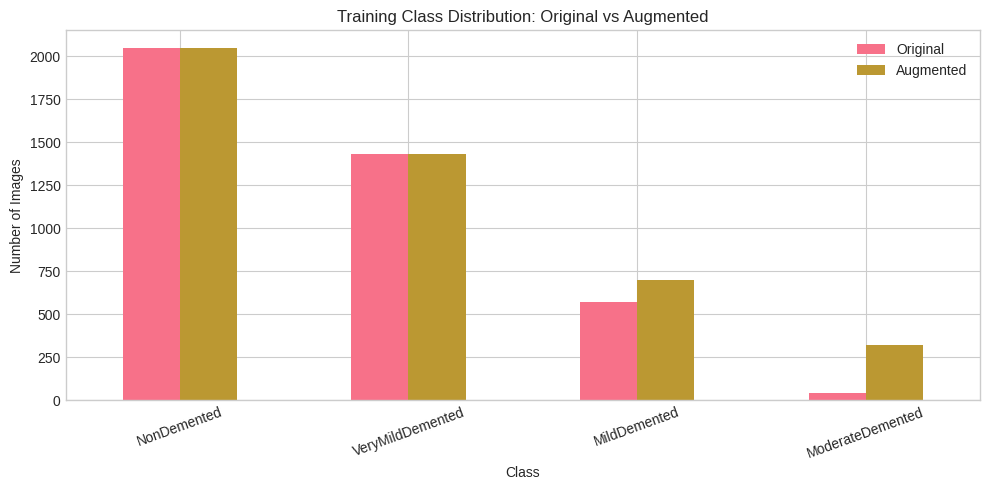

In [13]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


BATCH_SIZE = 64
NUM_WORKERS = 0 if IN_COLAB else 2
PIN_MEMORY = torch.cuda.is_available()

original_generator = torch.Generator().manual_seed(RANDOM_STATE)
augmented_generator = torch.Generator().manual_seed(RANDOM_STATE)

original_train_loader = DataLoader(
    original_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    generator=original_generator,
)
augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    generator=augmented_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
)

augmented_counts = Counter(label for _, label, _ in augmented_train_dataset.samples)
training_distribution = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Original': [Counter(train_labels)[i] for i in range(len(CLASS_NAMES))],
    'Augmented': [augmented_counts[i] for i in range(len(CLASS_NAMES))],
})
display(training_distribution)

training_distribution.set_index('Class').plot(kind='bar', figsize=(10, 5))
plt.title('Training Class Distribution: Original vs Augmented')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

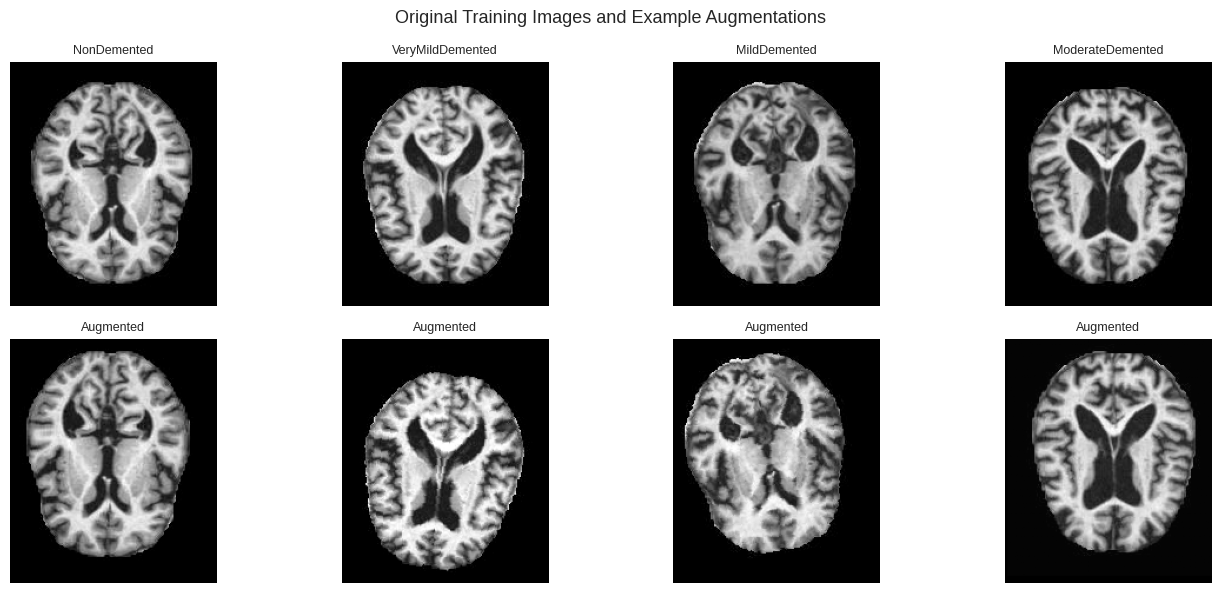

Example input batch shape: torch.Size([64, 1, 128, 128])
Example label batch shape: torch.Size([64])


In [14]:
fig, axes = plt.subplots(2, len(CLASS_NAMES), figsize=(14, 6))
fig.suptitle('Original Training Images and Example Augmentations', fontsize=13)

for class_index, class_name in enumerate(CLASS_NAMES):
    sample_path = next(
        path for path, label in zip(train_paths, train_labels)
        if label == class_index
    )
    original_image = Image.open(sample_path).convert('L')
    augmented_tensor = augmentation_transform(original_image)
    augmented_image = augmented_tensor.squeeze(0) * TRAIN_STD + TRAIN_MEAN

    axes[0, class_index].imshow(original_image, cmap='gray')
    axes[0, class_index].set_title(class_name, fontsize=9)
    axes[0, class_index].axis('off')

    axes[1, class_index].imshow(augmented_image.clamp(0, 1), cmap='gray')
    axes[1, class_index].set_title('Augmented', fontsize=9)
    axes[1, class_index].axis('off')

axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Augmented')
plt.tight_layout()
plt.show()

example_inputs, example_labels = next(iter(original_train_loader))
print(f"Example input batch shape: {example_inputs.shape}")
print(f"Example label batch shape: {example_labels.shape}")

## 6. CNN Architecture

The architecture uses convolution, activation, max pooling, dropout, flattening and fully connected layers. Repeated max pooling gradually reduces the 128×128 feature maps before they are passed to the fully connected layers.

In [15]:
class AlzheimerConvClassifier(nn.Module):
    def __init__(self, number_of_classes):
        super(AlzheimerConvClassifier, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(in_features=64 * 8 * 8, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=number_of_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(x)
        x = self.dropout1(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        logits = self.fc2(x)
        probabilities = F.softmax(logits, dim=1)

        return probabilities, logits

In [16]:
set_seed()
model_example = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES)).to(device)
print(model_example)
count_parameters(model_example)

with torch.no_grad():
    example_probabilities, example_logits = model_example(example_inputs.to(device))

print(f"Logit shape: {example_logits.shape}")
print(f"Probability shape: {example_probabilities.shape}")

AlzheimerConvClassifier(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)
Layer: conv1, Parameters: 160
Layer: conv2, Parameters: 4640
Layer: conv3, Parameters: 18496
Layer: pool, Parameters: 0
Layer: dropout1, Parameters: 0
Layer: dropout2, Parameters: 0
Layer: fc1, Parameters: 524416
Layer: fc2, Parameters: 516
Total parameters: 548228
Logit shape: torch.Size([64, 4])
Probability shape: torch.Size([64, 4])


## 7. Training Configuration

Both networks use the same architecture, initial parameters, loss function, optimizer settings and early-stopping rule. Only their training datasets differ.

In [17]:
MAX_EPOCHS = 60
LEARNING_RATE = 0.001
PATIENCE = 10
RETRAIN_MODELS = False

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ORIGINAL_MODEL_PATH = MODEL_DIR / 'alzheimer_cnn_non_augmented.pt'
AUGMENTED_MODEL_PATH = MODEL_DIR / 'alzheimer_cnn_augmented.pt'

criterion = nn.CrossEntropyLoss()

set_seed()
initial_model = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES))
initial_state = copy.deepcopy(initial_model.state_dict())
del initial_model

print(f"Maximum epochs: {MAX_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Early-stopping patience: {PATIENCE}")
print(f"Retrain existing models: {RETRAIN_MODELS}")
print(f"Model directory: {MODEL_DIR.resolve()}")

Maximum epochs: 60
Learning rate: 0.001
Early-stopping patience: 10
Retrain existing models: False
Model directory: /content/Deep-Learning-For-Human-Body-Marker-Augmentation/models


## 8. CNN Trained on the Non-Augmented Set

The first CNN is trained only on the original images in the training partition. Its best parameters are selected using validation loss.

In [18]:
set_seed()
original_generator.manual_seed(RANDOM_STATE)
original_model = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES)).to(device)

if ORIGINAL_MODEL_PATH.exists() and not RETRAIN_MODELS:
    checkpoint = torch.load(ORIGINAL_MODEL_PATH, map_location=device)
    original_model.load_state_dict(checkpoint['model_state_dict'])
    original_metrics = checkpoint['metrics']
    print(f"Loaded non-augmented model from {ORIGINAL_MODEL_PATH}")
else:
    original_model.load_state_dict(initial_state)
    original_optimizer = optim.Adam(original_model.parameters(), lr=LEARNING_RATE)
    original_metrics, _ = train_model(
        original_model,
        criterion,
        original_optimizer,
        MAX_EPOCHS,
        original_train_loader,
        validation_loader,
        patience=PATIENCE,
        model_name='Non-Augmented CNN'
    )
    torch.save(
        {
            'model_state_dict': original_model.state_dict(),
            'metrics': original_metrics,
            'class_names': CLASS_NAMES,
            'train_mean': float(TRAIN_MEAN),
            'train_std': float(TRAIN_STD),
            'random_state': RANDOM_STATE,
            'data_split': 'original_kaggle_test',
        },
        ORIGINAL_MODEL_PATH
    )
    print(f"Saved non-augmented model to {ORIGINAL_MODEL_PATH}")

Loaded non-augmented model from models/alzheimer_cnn_non_augmented.pt


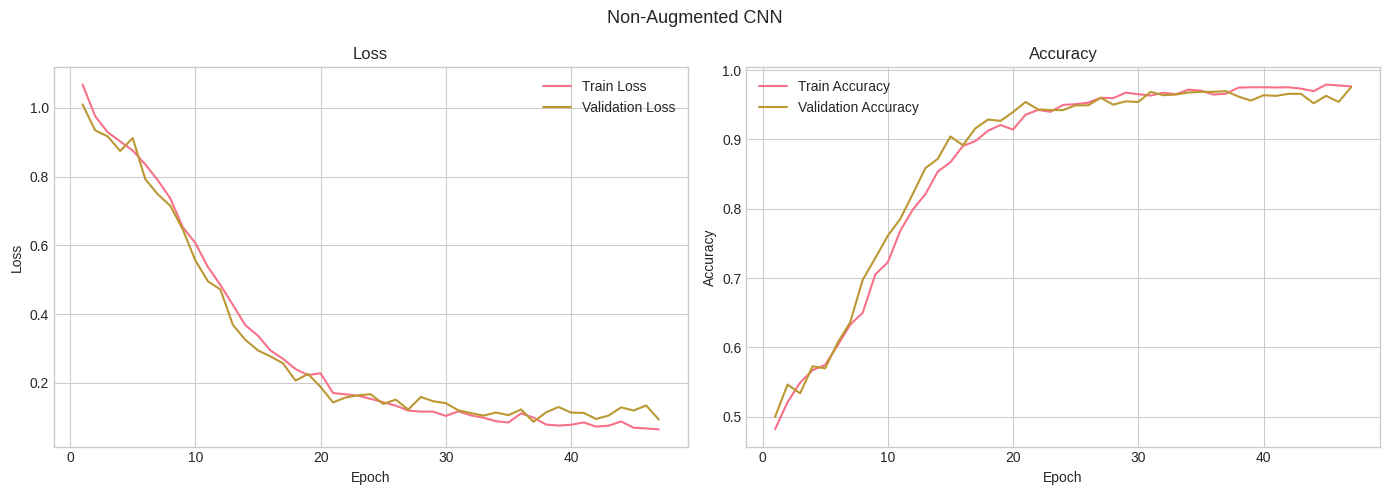

In [19]:
plot_training_metrics(original_metrics, title='Non-Augmented CNN')

## 9. CNN Trained on the Augmented Set

The second CNN starts from the same initial parameters and is trained on the targeted training-only augmented dataset. The validation set is identical to the one used for the first CNN.

In [20]:
set_seed()
augmented_generator.manual_seed(RANDOM_STATE)
augmented_model = AlzheimerConvClassifier(number_of_classes=len(CLASS_NAMES)).to(device)

if AUGMENTED_MODEL_PATH.exists() and not RETRAIN_MODELS:
    checkpoint = torch.load(AUGMENTED_MODEL_PATH, map_location=device)
    augmented_model.load_state_dict(checkpoint['model_state_dict'])
    augmented_metrics = checkpoint['metrics']
    print(f"Loaded augmented model from {AUGMENTED_MODEL_PATH}")
else:
    augmented_model.load_state_dict(initial_state)
    augmented_optimizer = optim.Adam(augmented_model.parameters(), lr=LEARNING_RATE)
    augmented_metrics, _ = train_model(
        augmented_model,
        criterion,
        augmented_optimizer,
        MAX_EPOCHS,
        augmented_train_loader,
        validation_loader,
        patience=PATIENCE,
        model_name='Augmented CNN'
    )
    torch.save(
        {
            'model_state_dict': augmented_model.state_dict(),
            'metrics': augmented_metrics,
            'class_names': CLASS_NAMES,
            'train_mean': float(TRAIN_MEAN),
            'train_std': float(TRAIN_STD),
            'random_state': RANDOM_STATE,
            'data_split': 'original_kaggle_test',
        },
        AUGMENTED_MODEL_PATH
    )
    print(f"Saved augmented model to {AUGMENTED_MODEL_PATH}")

Loaded augmented model from models/alzheimer_cnn_augmented.pt


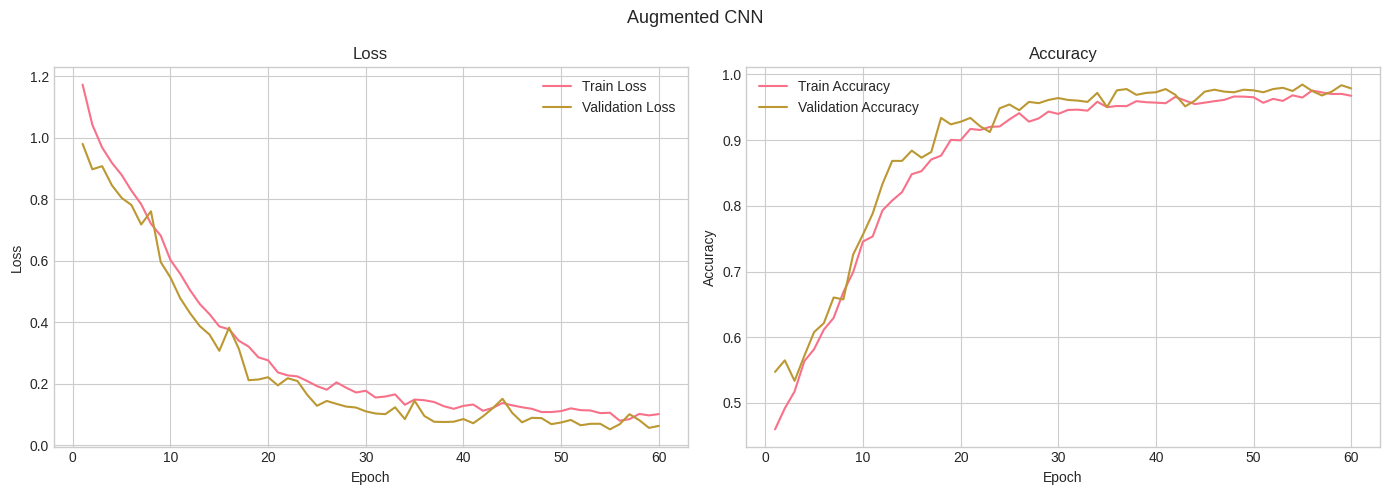

In [21]:
plot_training_metrics(augmented_metrics, title='Augmented CNN')

## 10. Test-Set Evaluation

The final models are evaluated once on Kaggle's original untouched 1,279-image test directory. The reported metrics are loss, accuracy, weighted precision, weighted recall, weighted F1 score and the confusion matrix.

Non-Augmented CNN
Loss     : 1.4658
Accuracy : 0.6857
Weighted Precision: 0.7020
Weighted Recall   : 0.6857
Weighted F1       : 0.6718
Macro F1          : 0.4929


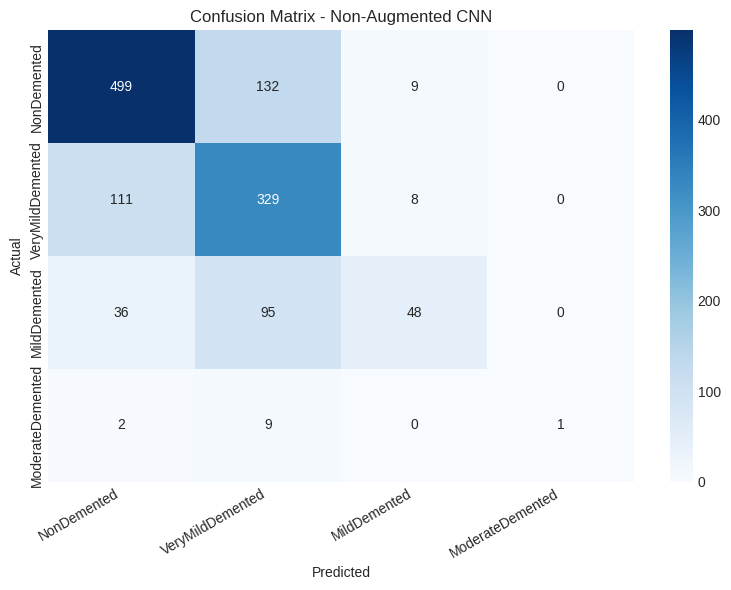

In [22]:
original_results = evaluate_model(
    original_model,
    criterion,
    test_loader,
    title='Non-Augmented CNN'
)

Augmented CNN
Loss     : 1.3802
Accuracy : 0.6458
Weighted Precision: 0.6782
Weighted Recall   : 0.6458
Weighted F1       : 0.6556
Macro F1          : 0.5678


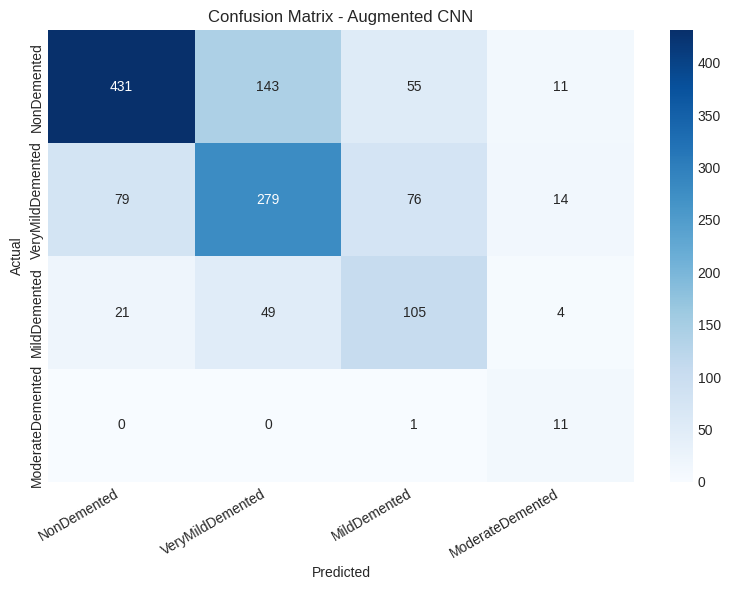

In [23]:
augmented_results = evaluate_model(
    augmented_model,
    criterion,
    test_loader,
    title='Augmented CNN'
)

,Test Loss,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1
Model,,,,,,
Non-Augmented CNN,1.4658,0.6857,0.7020,0.6857,0.6718,0.4929
Augmented CNN,1.3802,0.6458,0.6782,0.6458,0.6556,0.5678


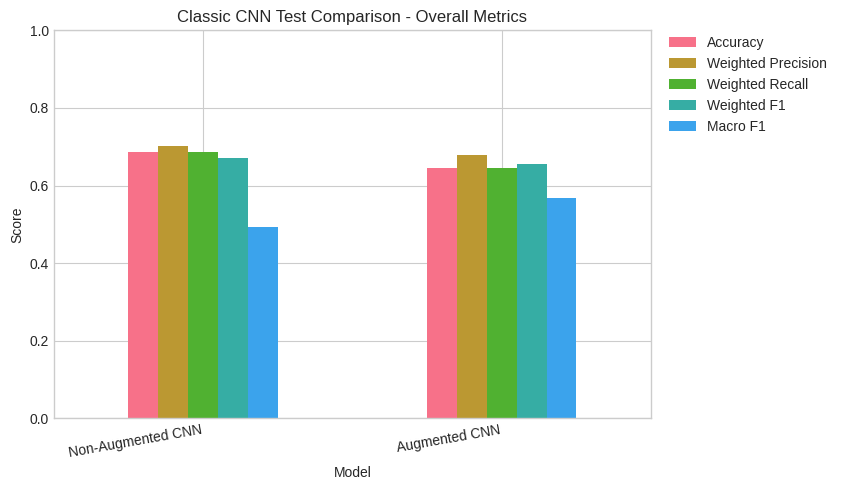

Per-Class Test Recall


,Non-Augmented CNN,Augmented CNN
Class,,
NonDemented,0.7797,0.6734
VeryMildDemented,0.7344,0.6228
MildDemented,0.2682,0.5866
ModerateDemented,0.0833,0.9167


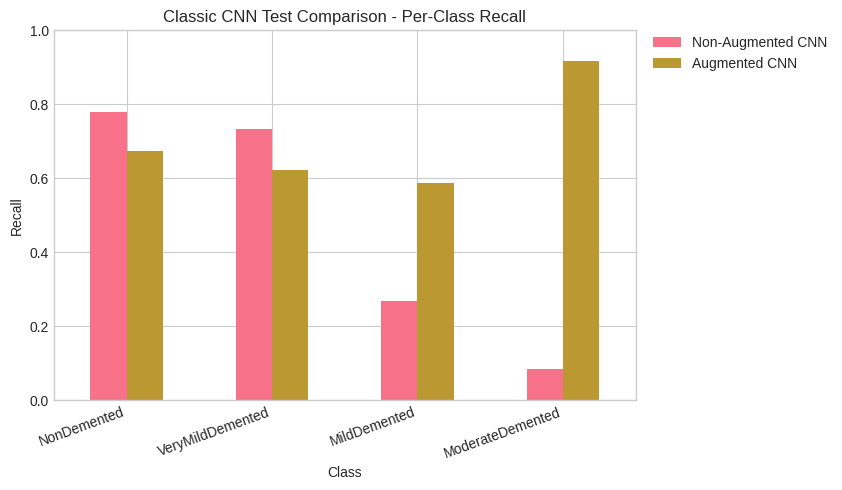

In [24]:
comparison, per_class_recall_comparison = compare_model_results(
    {
        'Non-Augmented CNN': original_results,
        'Augmented CNN': augmented_results,
    },
    title='Classic CNN Test Comparison',
)

## 11. Result Interpretation

After running both experiments, compare the learning curves, test metrics and confusion matrices. In particular, inspect whether augmentation improves recognition of the less frequent disease stages and whether either model begins to overfit according to the validation curves.

The original Kaggle test membership now matches the split used by the referenced Stanford project, making the headline test results substantially more comparable. Architecture, preprocessing, augmentation and metric-averaging differences still remain.

The `ModerateDemented` class contains only 12 Kaggle test images, so its result should be interpreted cautiously. A patient-level split would still be preferable if patient identifiers become available.

## 12. ResNet-50 Model and Search Configuration

The following experiment fine-tunes an ImageNet-pretrained ResNet-50. The pretrained RGB input weights are averaged into one channel so the model can reuse learned visual features while receiving the same grayscale 128×128 MRI images as the classic CNNs. The ImageNet classifier is replaced by the paper's 512- and 128-unit head, with dropout added for regularization. The search reuses the augmented training dataset and compares learning rates and Adam beta parameters.

In [25]:
from torchvision.models import ResNet50_Weights, resnet50


class AlzheimerResNet50(nn.Module):
    def __init__(
        self,
        number_of_classes,
        hidden_units,
        dropout_rate,
        initialize_from_imagenet=True,
    ):
        super().__init__()
        first_hidden, second_hidden = hidden_units

        weights = ResNet50_Weights.DEFAULT if initialize_from_imagenet else None
        self.resnet = resnet50(weights=weights)
        pretrained_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )
        if initialize_from_imagenet:
            with torch.no_grad():
                grayscale_weights = pretrained_conv.weight.mean(dim=1, keepdim=True)
                self.resnet.conv1.weight.copy_(grayscale_weights)
        input_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(input_features, first_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(first_hidden, second_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(second_hidden, number_of_classes),
        )

    def forward(self, x):
        logits = self.resnet(x)
        probabilities = F.softmax(logits, dim=1)
        return probabilities, logits


RESNET_HIDDEN_UNITS = (512, 128)
RESNET_DROPOUT_RATE = 0.3
RESNET_SEARCH_CONFIGS = []
for betas in ((0.9, 0.999), (0.963, 0.9997)):
    for learning_rate in (1e-4, 2.25e-4, 5e-4):
        RESNET_SEARCH_CONFIGS.append({
            'hidden_units': RESNET_HIDDEN_UNITS,
            'dropout_rate': RESNET_DROPOUT_RATE,
            'optimizer': 'Adam',
            'learning_rate': learning_rate,
            'betas': betas,
        })

RESNET_SEARCH_EPOCHS = 60
RESNET_SEARCH_PATIENCE = 10
RETRAIN_RESNET = False
RESNET_FILENAME = 'alzheimer_resnet50_best.pt'
RESNET_LOCAL_MODEL_PATH = MODEL_DIR / RESNET_FILENAME
RESNET_TRAINING_DIR = COLAB_MODEL_DIR if IN_COLAB else MODEL_DIR
RESNET_TRAINING_DIR.mkdir(parents=True, exist_ok=True)
RESNET_PERSISTENT_MODEL_PATH = RESNET_TRAINING_DIR / RESNET_FILENAME
RESNET_SEARCH_STATE_PATH = RESNET_TRAINING_DIR / 'alzheimer_resnet50_pretrained_search_state.pt'

if not RETRAIN_RESNET and RESNET_LOCAL_MODEL_PATH.exists():
    RESNET_MODEL_PATH = RESNET_LOCAL_MODEL_PATH
elif not RETRAIN_RESNET and RESNET_PERSISTENT_MODEL_PATH.exists():
    RESNET_MODEL_PATH = RESNET_PERSISTENT_MODEL_PATH
else:
    RESNET_MODEL_PATH = RESNET_PERSISTENT_MODEL_PATH

print(f'ResNet-50 configurations: {len(RESNET_SEARCH_CONFIGS)}')
print(f'Maximum epochs per configuration: {RESNET_SEARCH_EPOCHS}')
print(f'Early-stopping patience: {RESNET_SEARCH_PATIENCE}')
print(f'ImageNet pretrained: True')
print(f'Classifier dropout: {RESNET_DROPOUT_RATE}')
print(f'Retrain existing ResNet-50: {RETRAIN_RESNET}')
print(f'Mixed precision: {USE_AMP}')
print(f'Model path: {RESNET_MODEL_PATH.resolve()}')

ResNet-50 configurations: 6
Maximum epochs per configuration: 60
Early-stopping patience: 10
ImageNet pretrained: True
Classifier dropout: 0.3
Retrain existing ResNet-50: False
Mixed precision: True
Model path: /content/Deep-Learning-For-Human-Body-Marker-Augmentation/models/alzheimer_resnet50_best.pt


In [26]:
set_seed()
resnet_example = AlzheimerResNet50(
    number_of_classes=len(CLASS_NAMES),
    hidden_units=RESNET_HIDDEN_UNITS,
    dropout_rate=RESNET_DROPOUT_RATE,
    initialize_from_imagenet=True,
).to(device)

with torch.no_grad():
    resnet_probabilities, resnet_logits = resnet_example(example_inputs.to(device))

print(f'Logit shape: {resnet_logits.shape}')
print(f'Probability shape: {resnet_probabilities.shape}')
count_parameters(resnet_example)
del resnet_example
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]


Logit shape: torch.Size([64, 4])
Probability shape: torch.Size([64, 4])
Layer: resnet, Parameters: 24617028
Total parameters: 24617028


## 13. Hyperparameter Search and Model Selection

Each of the six Adam configurations fine-tunes the same ImageNet-pretrained ResNet-50 with identical data, augmentation, classifier size, dropout, initialization seed and early stopping. The search compares three learning rates with standard Adam betas and the paper's tuned betas for up to 60 epochs. The best checkpoint within each run and the winning configuration across runs are selected by validation macro F1, with validation loss used to break ties. Only the winning model is retained and saved.

In [27]:
def build_resnet_optimizer(model, config):
    return optim.Adam(
        model.parameters(),
        lr=config['learning_rate'],
        betas=config['betas'],
    )

Loaded selected ResNet-50 from models/alzheimer_resnet50_best.pt


,Trial,Optimizer,Learning Rate,Hidden Units,Dropout,Best Epoch,Validation Macro F1,Validation Loss,Validation Accuracy,Training Seconds
0,5,Adam,0.0002,"(512, 128)",0.3,20,0.9894,0.0419,0.9863,319.2731
1,6,Adam,0.0005,"(512, 128)",0.3,23,0.9886,0.0838,0.9854,364.2574
2,4,Adam,0.0001,"(512, 128)",0.3,42,0.9827,0.0946,0.9805,547.8615
3,3,Adam,0.0005,"(512, 128)",0.3,7,0.9818,0.0637,0.9766,183.3891
4,1,Adam,0.0001,"(512, 128)",0.3,19,0.9808,0.0829,0.9795,303.8936
5,2,Adam,0.0002,"(512, 128)",0.3,21,0.9803,0.0817,0.9766,314.6920


Selected configuration:


,0
hidden_units,"(512, 128)"
dropout_rate,0.3
optimizer,Adam
learning_rate,0.000225
betas,"(0.963, 0.9997)"


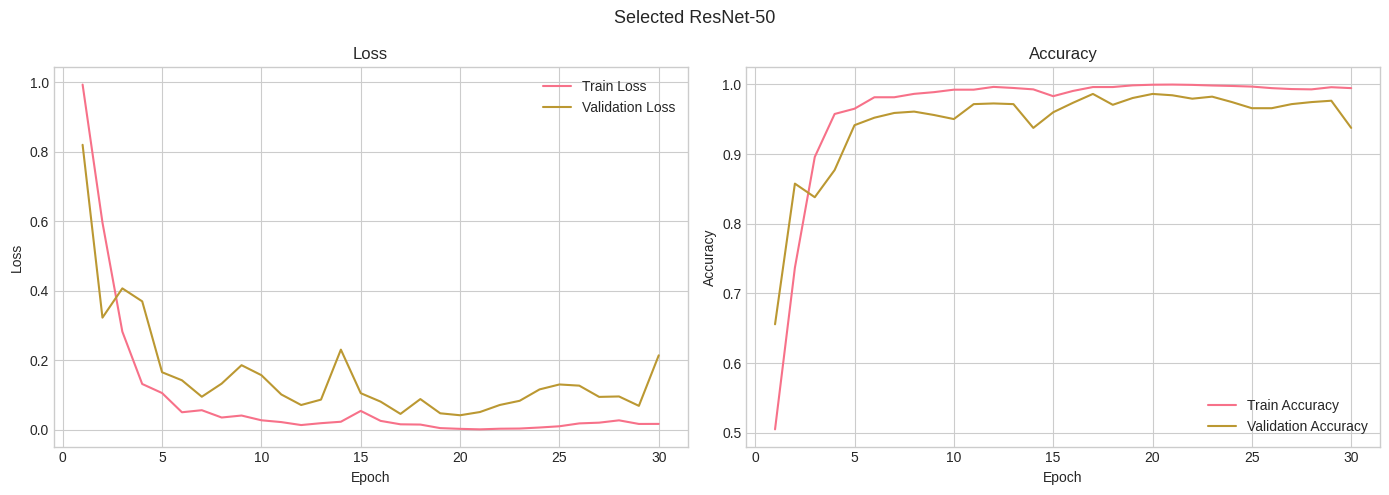

In [28]:
if RESNET_MODEL_PATH.exists() and not RETRAIN_RESNET:
    resnet_checkpoint = torch.load(
        RESNET_MODEL_PATH,
        map_location=device,
        weights_only=False,
    )
    best_resnet_config = resnet_checkpoint['config']
    best_resnet_config['hidden_units'] = tuple(best_resnet_config['hidden_units'])
    resnet_search_results = pd.DataFrame(resnet_checkpoint['search_results'])
    resnet_metrics = resnet_checkpoint['metrics']
    best_resnet_model = AlzheimerResNet50(
        number_of_classes=len(CLASS_NAMES),
        hidden_units=best_resnet_config['hidden_units'],
        dropout_rate=best_resnet_config.get('dropout_rate', RESNET_DROPOUT_RATE),
        initialize_from_imagenet=False,
    ).to(device)
    best_resnet_model.load_state_dict(resnet_checkpoint['model_state_dict'])
    print(f'Loaded selected ResNet-50 from {RESNET_MODEL_PATH}')
else:
    search_rows = []
    best_resnet_state = None
    best_resnet_config = None
    resnet_metrics = None
    best_search_score = (-1.0, float('-inf'))
    completed_trials = set()

    if RESNET_SEARCH_STATE_PATH.exists():
        search_state = torch.load(
            RESNET_SEARCH_STATE_PATH,
            map_location='cpu',
            weights_only=False,
        )
        if search_state['search_configs'] != RESNET_SEARCH_CONFIGS:
            raise ValueError(
                'The saved ResNet search uses different configurations. '
                'Remove the search-state file or restore the original configuration list.'
            )
        search_rows = search_state['search_rows']
        completed_trials = set(search_state['completed_trials'])
        best_resnet_state = search_state['best_resnet_state']
        best_resnet_config = search_state['best_resnet_config']
        resnet_metrics = search_state['metrics']
        best_search_score = tuple(search_state['best_search_score'])
        print(
            f'Resuming ResNet-50 search with {len(completed_trials)} of '
            f'{len(RESNET_SEARCH_CONFIGS)} trials complete.'
        )

    search_progress = tqdm(
        range(1, len(RESNET_SEARCH_CONFIGS) + 1),
        desc='ResNet-50 search',
    )
    for trial_number in search_progress:
        if trial_number in completed_trials:
            continue

        config = RESNET_SEARCH_CONFIGS[trial_number - 1]
        set_seed()
        augmented_generator.manual_seed(RANDOM_STATE)
        trial_model = AlzheimerResNet50(
            number_of_classes=len(CLASS_NAMES),
            hidden_units=config['hidden_units'],
            dropout_rate=config['dropout_rate'],
            initialize_from_imagenet=True,
        ).to(device)
        trial_optimizer = build_resnet_optimizer(trial_model, config)
        trial_name = (
            f'ResNet trial {trial_number}/{len(RESNET_SEARCH_CONFIGS)} | '
            f"{config['optimizer']} lr={config['learning_rate']:g} "
            f"head={config['hidden_units']}"
        )

        started_at = time.perf_counter()
        trial_metrics, selection = train_model(
            trial_model,
            criterion,
            trial_optimizer,
            RESNET_SEARCH_EPOCHS,
            augmented_train_loader,
            validation_loader,
            patience=RESNET_SEARCH_PATIENCE,
            model_name=trial_name,
            selection_metric='val_macro_f1',
            use_amp=USE_AMP,
        )
        training_seconds = time.perf_counter() - started_at

        search_rows.append({
            'Trial': trial_number,
            'Optimizer': config['optimizer'],
            'Learning Rate': config['learning_rate'],
            'Hidden Units': str(config['hidden_units']),
            'Dropout': config['dropout_rate'],
            'Best Epoch': selection['best_epoch'],
            'Validation Macro F1': selection['val_macro_f1'],
            'Validation Loss': selection['val_loss'],
            'Validation Accuracy': selection['val_accuracy'],
            'Training Seconds': training_seconds,
        })

        trial_score = (selection['val_macro_f1'], -selection['val_loss'])
        if trial_score > best_search_score:
            best_search_score = trial_score
            best_resnet_state = state_dict_to_cpu(trial_model)
            best_resnet_config = copy.deepcopy(config)
            resnet_metrics = copy.deepcopy(trial_metrics)

        completed_trials.add(trial_number)
        search_state = {
            'search_rows': search_rows,
            'completed_trials': sorted(completed_trials),
            'best_resnet_state': best_resnet_state,
            'best_resnet_config': best_resnet_config,
            'metrics': resnet_metrics,
            'best_search_score': best_search_score,
            'search_configs': RESNET_SEARCH_CONFIGS,
            'random_state': RANDOM_STATE,
        }
        temporary_search_path = RESNET_SEARCH_STATE_PATH.with_suffix('.tmp')
        torch.save(search_state, temporary_search_path)
        temporary_search_path.replace(RESNET_SEARCH_STATE_PATH)
        search_progress.set_postfix({
            'completed': f'{len(completed_trials)}/{len(RESNET_SEARCH_CONFIGS)}',
            'best_f1': f'{best_search_score[0]:.4f}',
        })

        trial_model.cpu()
        del trial_model, trial_optimizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    resnet_search_results = pd.DataFrame(search_rows).sort_values(
        ['Validation Macro F1', 'Validation Loss'],
        ascending=[False, True],
    ).reset_index(drop=True)

    best_resnet_model = AlzheimerResNet50(
        number_of_classes=len(CLASS_NAMES),
        hidden_units=best_resnet_config['hidden_units'],
        dropout_rate=best_resnet_config['dropout_rate'],
        initialize_from_imagenet=False,
    ).to(device)
    best_resnet_model.load_state_dict(best_resnet_state)

    final_checkpoint = {
        'model_state_dict': best_resnet_state,
        'config': best_resnet_config,
        'search_results': resnet_search_results.to_dict('records'),
        'metrics': resnet_metrics,
        'class_names': CLASS_NAMES,
        'train_mean': float(TRAIN_MEAN),
        'train_std': float(TRAIN_STD),
        'random_state': RANDOM_STATE,
        'data_split': 'original_kaggle_test',
        'selection_metric': 'validation_macro_f1',
        'imagenet_pretrained': True,
        'input_channels': 1,
        'input_size': (128, 128),
        'mixed_precision': USE_AMP,
    }
    temporary_model_path = RESNET_MODEL_PATH.with_suffix('.tmp')
    torch.save(final_checkpoint, temporary_model_path)
    temporary_model_path.replace(RESNET_MODEL_PATH)
    RESNET_SEARCH_STATE_PATH.unlink(missing_ok=True)
    print(f'Saved selected ResNet-50 to {RESNET_MODEL_PATH}')

display(resnet_search_results.round(4))
print('Selected configuration:')
display(pd.Series(best_resnet_config))
plot_training_metrics(resnet_metrics, title='Selected ResNet-50')

## 14. Selected ResNet-50 Test Evaluation

After hyperparameter selection is complete, the saved winning model is evaluated once on the untouched Kaggle test set using the same metrics and confusion-matrix function as the classic CNNs.

Selected ResNet-50
Loss     : 1.1697
Accuracy : 0.7686
Weighted Precision: 0.7743
Weighted Recall   : 0.7686
Weighted F1       : 0.7698
Macro F1          : 0.7916


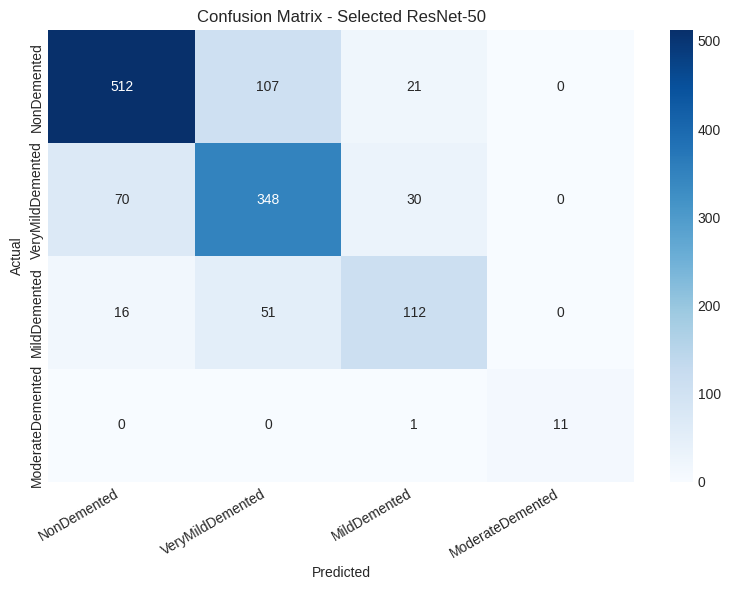

In [29]:
resnet_results = evaluate_model(
    best_resnet_model,
    criterion,
    test_loader,
    title='Selected ResNet-50',
)

## 15. Final Model Comparison

The selected ResNet-50 is added to the earlier test-set table and per-class recall plot, allowing its overall and minority-class performance to be compared directly with both classic CNN runs.

,Test Loss,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1
Model,,,,,,
Non-Augmented CNN,1.4658,0.6857,0.7020,0.6857,0.6718,0.4929
Augmented CNN,1.3802,0.6458,0.6782,0.6458,0.6556,0.5678
Selected ResNet-50,1.1697,0.7686,0.7743,0.7686,0.7698,0.7916


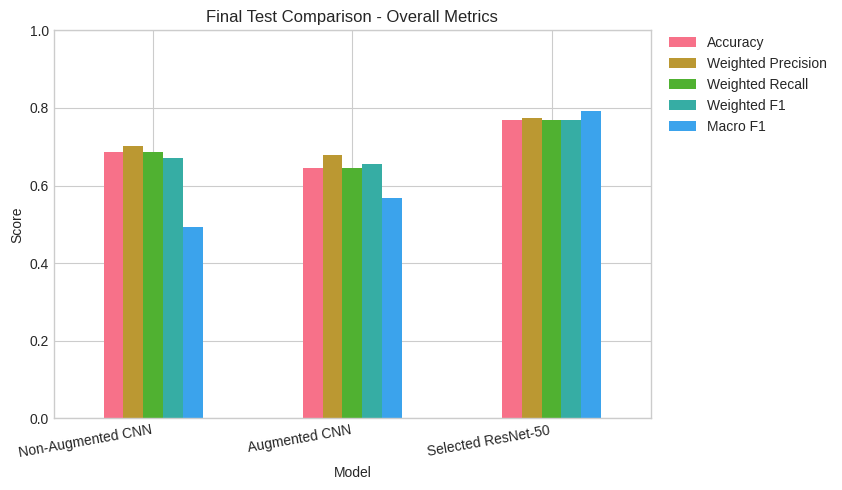

Per-Class Test Recall


,Non-Augmented CNN,Augmented CNN,Selected ResNet-50
Class,,,
NonDemented,0.7797,0.6734,0.8000
VeryMildDemented,0.7344,0.6228,0.7768
MildDemented,0.2682,0.5866,0.6257
ModerateDemented,0.0833,0.9167,0.9167


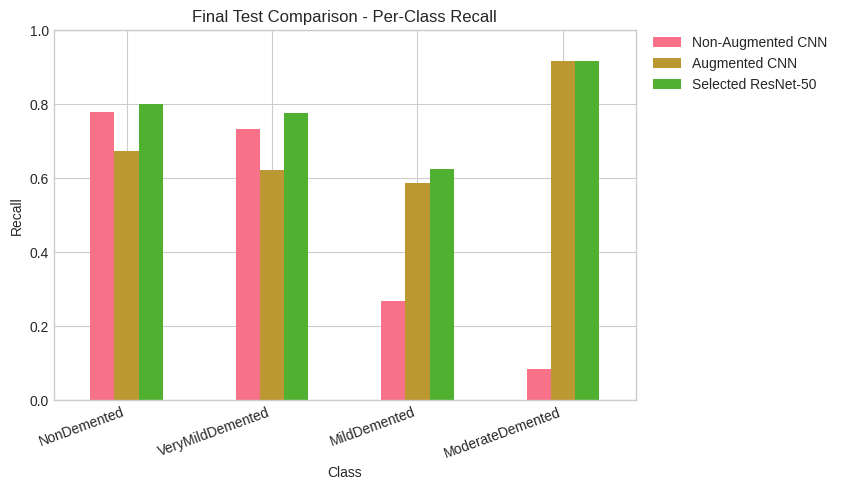

In [30]:
final_comparison, final_per_class_recall = compare_model_results(
    {
        'Non-Augmented CNN': original_results,
        'Augmented CNN': augmented_results,
        'Selected ResNet-50': resnet_results,
    },
    title='Final Test Comparison',
)

## 16. Supervised Contrastive Learning Components

Supervised contrastive learning replaces the cross-entropy objective with one that shapes the representation space directly. Every image is transformed twice, both views are encoded, and the loss pulls views of the same class together while pushing the other classes apart. A classifier is trained afterwards on the resulting representations.

The encoder reuses the grayscale ResNet construction from the previous section, with the ImageNet classifier replaced by an identity so the pooled representation is returned unchanged. A projection head maps that representation onto a unit sphere, where the loss is computed, and is discarded once pretraining is complete.

Only the training partition is resampled. The validation and test loaders, the normalization statistics and the splits themselves are reused exactly as they are, so the results reported earlier remain valid.

The final cell instantiates the encoder once to confirm the shapes it produces, reports the loss at two temperatures, and prints the class counts of a sampled batch. Those counts matter because the loss can only form positive pairs for a class that is actually present in the batch, and ModerateDemented contributes 42 of the 4,096 training images.

In [31]:
from torch.utils.data import WeightedRandomSampler
from torchvision.models import ResNet18_Weights, resnet18

In [32]:
class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature):
        super(SupervisedContrastiveLoss, self).__init__()
        self.temperature = temperature

    def forward(self, projections, labels):
        number_of_views = projections.size(1)
        features = projections.flatten(0, 1).float()
        feature_labels = labels.repeat_interleave(number_of_views)
        number_of_features = features.size(0)

        similarities = torch.matmul(features, features.T) / self.temperature
        similarities = similarities - similarities.max(dim=1, keepdim=True)[0].detach()

        is_self = torch.eye(number_of_features, dtype=torch.bool, device=features.device)
        is_positive = (
            feature_labels.unsqueeze(0) == feature_labels.unsqueeze(1)
        ) & ~is_self

        exponentiated = torch.exp(similarities).masked_fill(is_self, 0.0)
        log_probabilities = similarities - torch.log(exponentiated.sum(dim=1, keepdim=True))

        positive_log_probabilities = (is_positive * log_probabilities).sum(dim=1)
        positive_counts = is_positive.sum(dim=1)
        has_positives = positive_counts > 0

        return -(
            positive_log_probabilities[has_positives] / positive_counts[has_positives]
        ).mean()

In [33]:
class ContrastiveMRIDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image = Image.open(self.paths[index]).convert('L').resize((128, 128))
        first_view = self.transform(image)
        second_view = self.transform(image)
        label = int(self.labels[index])
        return torch.stack([first_view, second_view]), label


contrastive_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomResizedCrop(128, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply(
        [transforms.ColorJitter(brightness=0.4, contrast=0.4)],
        p=0.8
    ),
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0))],
        p=0.5
    ),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((TRAIN_MEAN,), (TRAIN_STD,)),
])

CONTRASTIVE_BATCH_SIZE = 128
CONTRASTIVE_NUM_WORKERS = 2
BALANCED_SAMPLING_POWER = 1.0

contrastive_train_dataset = ContrastiveMRIDataset(
    train_paths,
    train_labels,
    contrastive_transform
)

train_class_counts = Counter(int(label) for label in train_labels)
balanced_weights = [
    1.0 / train_class_counts[int(label)] ** BALANCED_SAMPLING_POWER
    for label in train_labels
]
balanced_sampler = WeightedRandomSampler(
    balanced_weights,
    num_samples=len(train_labels),
    replacement=True,
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)

contrastive_generator = torch.Generator().manual_seed(RANDOM_STATE)
contrastive_train_loader = DataLoader(
    contrastive_train_dataset,
    batch_size=CONTRASTIVE_BATCH_SIZE,
    sampler=balanced_sampler,
    num_workers=CONTRASTIVE_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    generator=contrastive_generator,
    drop_last=True,
)

print(f"Contrastive training images: {len(contrastive_train_dataset)}")
print(f"Batch size: {CONTRASTIVE_BATCH_SIZE}")
print(f"Balanced sampling power: {BALANCED_SAMPLING_POWER}")
print(f"Batches per epoch: {len(contrastive_train_loader)}")

Contrastive training images: 4096
Batch size: 128
Balanced sampling power: 1.0
Batches per epoch: 32


In [34]:
class AlzheimerContrastiveEncoder(nn.Module):
    def __init__(
        self,
        backbone,
        projection_units,
        projection_dimensions,
        initialize_from_imagenet=True,
    ):
        super(AlzheimerContrastiveEncoder, self).__init__()

        if backbone == 'resnet50':
            weights = ResNet50_Weights.DEFAULT if initialize_from_imagenet else None
            self.resnet = resnet50(weights=weights)
        else:
            weights = ResNet18_Weights.DEFAULT if initialize_from_imagenet else None
            self.resnet = resnet18(weights=weights)

        pretrained_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )
        if initialize_from_imagenet:
            with torch.no_grad():
                grayscale_weights = pretrained_conv.weight.mean(dim=1, keepdim=True)
                self.resnet.conv1.weight.copy_(grayscale_weights)

        self.backbone = backbone
        self.representation_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()
        self.projection = nn.Sequential(
            nn.Linear(self.representation_features, projection_units),
            nn.ReLU(inplace=True),
            nn.Linear(projection_units, projection_dimensions),
        )

    def forward(self, x):
        representations = self.resnet(x)
        projections = F.normalize(self.projection(representations), dim=1)

        return representations, projections


CONTRASTIVE_PROJECTION_UNITS = 512
CONTRASTIVE_PROJECTION_DIMENSIONS = 128

print(f"Projection head: {CONTRASTIVE_PROJECTION_UNITS} -> {CONTRASTIVE_PROJECTION_DIMENSIONS}")

Projection head: 512 -> 128


In [35]:
set_seed()
encoder_example = AlzheimerContrastiveEncoder(
    backbone='resnet50',
    projection_units=CONTRASTIVE_PROJECTION_UNITS,
    projection_dimensions=CONTRASTIVE_PROJECTION_DIMENSIONS,
).to(device)

example_views, example_view_labels = next(iter(contrastive_train_loader))
number_of_images, number_of_views = example_views.shape[:2]

with torch.no_grad():
    example_representations, example_projections = encoder_example(
        example_views.flatten(0, 1).to(device)
    )
example_projections = example_projections.view(number_of_images, number_of_views, -1)

print(f"View batch shape: {example_views.shape}")
print(f"Representation shape: {example_representations.shape}")
print(f"Projection shape: {example_projections.shape}")
print(f"Projection norm: {example_projections[0, 0].norm().item():.4f}")

for temperature in (0.05, 0.2):
    contrastive_criterion = SupervisedContrastiveLoss(temperature)
    loss = contrastive_criterion(example_projections, example_view_labels.to(device))
    print(f"Loss at temperature {temperature}: {loss.item():.4f}")

balanced_counts = Counter(example_view_labels.tolist())
print("Class counts in one balanced batch:")
for class_index, class_name in enumerate(CLASS_NAMES):
    print(f"  {class_name}: {balanced_counts[class_index]}")

del encoder_example
if torch.cuda.is_available():
    torch.cuda.empty_cache()

View batch shape: torch.Size([128, 2, 1, 128, 128])
Representation shape: torch.Size([256, 2048])
Projection shape: torch.Size([128, 2, 128])
Projection norm: 1.0000
Loss at temperature 0.05: 6.4266
Loss at temperature 0.2: 5.5976
Class counts in one balanced batch:
  NonDemented: 34
  VeryMildDemented: 33
  MildDemented: 32
  ModerateDemented: 29


## 17. Encoder Pretraining

Pretraining optimizes the encoder alone. No classifier is attached and no labels are predicted; the labels are used only to decide which samples in a batch count as positives.

Progress is monitored on the validation dataset built earlier, which applies no augmentation and keeps the natural class distribution. It is re-wrapped only to match the contrastive batch size and to drop the trailing partial batch, because a batch holding a single image has no positive to pair with. Each validation image contributes one view, so the loss there measures only how well the classes are separated, while the training loss also rewards agreement between two augmented views of the same image. The two values are tracked separately and compared across epochs rather than against each other.

The best epoch is selected by validation loss and early stopping follows the rule used for the earlier models. The projection head takes part in pretraining but is dropped afterwards; only the encoder is carried forward to the classification stage.

In [36]:
contrastive_validation_loader = DataLoader(
    validation_dataset,
    batch_size=CONTRASTIVE_BATCH_SIZE,
    shuffle=False,
    num_workers=CONTRASTIVE_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    drop_last=True,
)

print(f"Validation images monitored: "
      f"{len(contrastive_validation_loader) * CONTRASTIVE_BATCH_SIZE}"
      f" of {len(validation_dataset)}")
print(f"Validation batches per epoch: {len(contrastive_validation_loader)}")

Validation images monitored: 1024 of 1025
Validation batches per epoch: 8


In [37]:
def pretrain_encoder(
    encoder,
    criterion,
    optimizer,
    num_epochs,
    train_loader,
    val_loader,
    patience=10,
    model_name='Encoder',
    use_amp=None,
):
    metrics = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'epoch_seconds': [],
    }

    dev = get_device()
    use_amp = dev.type == 'cuda' if use_amp is None else use_amp
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    best_state = state_dict_to_cpu(encoder)
    best_val_loss = float('inf')
    best_train_loss = float('inf')
    best_epoch = 0
    epochs_without_improvement = 0

    pbar = tqdm(range(1, num_epochs + 1), desc=f'{model_name} progress')
    for epoch in pbar:
        epoch_started_at = time.perf_counter()
        pbar.set_description(f'{model_name} | Epoch {epoch}/{num_epochs}')
        encoder.train()
        train_loss = 0.0
        train_total = 0

        train_batches = tqdm(
            train_loader,
            desc=f'Pretraining epoch {epoch}/{num_epochs}',
            leave=False
        )
        for views, labels in train_batches:
            views, labels = bind_gpu((views, labels))
            number_of_images, number_of_views = views.shape[:2]

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=dev.type, enabled=use_amp):
                _, projections = encoder(views.flatten(0, 1))
            projections = projections.view(number_of_images, number_of_views, -1)
            loss = criterion(projections, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * number_of_images
            train_total += number_of_images
            train_batches.set_postfix({'batch_loss': f'{loss.item():.4f}'})

        train_loss /= train_total

        encoder.eval()
        val_loss = 0.0
        val_total = 0

        with torch.no_grad():
            validation_batches = tqdm(
                val_loader,
                desc=f'Validation epoch {epoch}/{num_epochs}',
                leave=False
            )
            for inputs, labels in validation_batches:
                inputs, labels = bind_gpu((inputs, labels))
                with torch.autocast(device_type=dev.type, enabled=use_amp):
                    _, projections = encoder(inputs)
                loss = criterion(projections.unsqueeze(1), labels)

                batch_size = labels.size(0)
                val_loss += loss.item() * batch_size
                val_total += batch_size

        val_loss /= val_total

        metrics['epoch'].append(epoch)
        metrics['train_loss'].append(train_loss)
        metrics['val_loss'].append(val_loss)
        metrics['epoch_seconds'].append(time.perf_counter() - epoch_started_at)

        if val_loss < best_val_loss:
            best_state = state_dict_to_cpu(encoder)
            best_val_loss = val_loss
            best_train_loss = train_loss
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        pbar.set_postfix({
            'train_loss': f'{train_loss:.4f}',
            'val_loss': f'{val_loss:.4f}',
            'epoch_min': f"{metrics['epoch_seconds'][-1] / 60:.1f}",
        })

        if epochs_without_improvement >= patience:
            print(f"Early stopping after epoch {epoch}.")
            break

    encoder.load_state_dict(best_state)
    selection = {
        'best_epoch': best_epoch,
        'train_loss': best_train_loss,
        'val_loss': best_val_loss,
    }
    print(
        f'Best epoch: {best_epoch} | training loss: {best_train_loss:.4f} | '
        f'validation loss: {best_val_loss:.4f}'
    )
    return metrics, selection

In [38]:
def plot_contrastive_metrics(metrics, title=''):
    plt.figure(figsize=(7, 5))
    plt.plot(metrics['epoch'], metrics['train_loss'], label='Train Loss (two views)')
    plt.plot(metrics['epoch'], metrics['val_loss'], label='Validation Loss (one view)')
    plt.xlabel('Epoch')
    plt.ylabel('Supervised Contrastive Loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


print("Pretraining helpers defined.")

Pretraining helpers defined.


## 18. Temperature Search and Encoder Selection

The temperature divides every similarity before the softmax and decides how sharply the loss reacts to the negatives closest to an anchor. A low value concentrates almost all of the gradient on the hardest negatives, which needs a large pool of them to be reliable; a high value spreads the gradient more evenly. The referenced project settled on 0.05 with a batch of 64. Our batches hold 128 images, which is still a small pool of negatives by the standards of this loss, so the search keeps 0.05 and probes upwards from it with 0.07, 0.1 and 0.2. Nothing below 0.05 is tried: the expectation being tested is that a softer temperature is the more stable choice at this batch size, and a sharper one would move in the direction the pool size already makes unreliable.

Each trial pretrains a fresh ImageNet-initialized encoder and then measures it the way it will actually be used: the encoder is frozen, representations are extracted for the training and validation partitions with the plain transform, and a linear classifier is fitted on those cached vectors. Because the classifier trains on 2,048-dimensional vectors rather than images, this costs seconds per trial and compares the temperatures on the representation that is kept, not on the projection that is discarded.

The optimizer stays Adam, as everywhere else in the notebook, so that the comparison against the cross-entropy ResNet-50 differs in the objective alone. The learning rate is searched rather than assumed, over the value the referenced project reports for this loss and the value the earlier ResNet search selected on the same data.

Trials are selected by validation macro F1 from that linear probe, with the probe's accuracy breaking ties. The validation contrastive loss is reported for each trial but never used to rank them, because dividing by the temperature changes the scale of the loss: a lower temperature inflates it regardless of how good the encoder is, so ranking by it would quietly favour the higher temperatures. The sampler and loader generators are reset before every trial so each configuration sees the same sequence of images, and the search state is written after each trial so an interrupted session resumes where it stopped.

In [39]:
CONTRASTIVE_TEMPERATURES = (0.05, 0.07, 0.1, 0.2)
CONTRASTIVE_LEARNING_RATES = (2.25e-4, 1e-3)
CONTRASTIVE_SEARCH_CONFIGS = []
for learning_rate in CONTRASTIVE_LEARNING_RATES:
    for temperature in CONTRASTIVE_TEMPERATURES:
        CONTRASTIVE_SEARCH_CONFIGS.append({
            'backbone': 'resnet50',
            'temperature': temperature,
            'projection_units': CONTRASTIVE_PROJECTION_UNITS,
            'projection_dimensions': CONTRASTIVE_PROJECTION_DIMENSIONS,
            'optimizer': 'Adam',
            'learning_rate': learning_rate,
            'betas': (0.9, 0.999),
        })

CONTRASTIVE_SEARCH_EPOCHS = 60
CONTRASTIVE_SEARCH_PATIENCE = 10
CONTRASTIVE_PROBE_EPOCHS = 500
CONTRASTIVE_PROBE_LEARNING_RATE = 0.01
RETRAIN_CONTRASTIVE = False

CONTRASTIVE_FILENAME = 'alzheimer_supcon_resnet50_best.pt'
CONTRASTIVE_LOCAL_MODEL_PATH = MODEL_DIR / CONTRASTIVE_FILENAME
CONTRASTIVE_TRAINING_DIR = COLAB_MODEL_DIR if IN_COLAB else MODEL_DIR
CONTRASTIVE_TRAINING_DIR.mkdir(parents=True, exist_ok=True)
CONTRASTIVE_PERSISTENT_MODEL_PATH = CONTRASTIVE_TRAINING_DIR / CONTRASTIVE_FILENAME
CONTRASTIVE_SEARCH_STATE_PATH = (
    CONTRASTIVE_TRAINING_DIR / 'alzheimer_supcon_search_state.pt'
)

if not RETRAIN_CONTRASTIVE and CONTRASTIVE_LOCAL_MODEL_PATH.exists():
    CONTRASTIVE_MODEL_PATH = CONTRASTIVE_LOCAL_MODEL_PATH
elif not RETRAIN_CONTRASTIVE and CONTRASTIVE_PERSISTENT_MODEL_PATH.exists():
    CONTRASTIVE_MODEL_PATH = CONTRASTIVE_PERSISTENT_MODEL_PATH
else:
    CONTRASTIVE_MODEL_PATH = CONTRASTIVE_PERSISTENT_MODEL_PATH

print(f'Temperatures: {CONTRASTIVE_TEMPERATURES}')
print(f'Learning rates: {CONTRASTIVE_LEARNING_RATES}')
print(f'Configurations: {len(CONTRASTIVE_SEARCH_CONFIGS)}')
print(f'Maximum epochs per configuration: {CONTRASTIVE_SEARCH_EPOCHS}')
print(f'Early-stopping patience: {CONTRASTIVE_SEARCH_PATIENCE}')
print(f'Retrain existing encoder: {RETRAIN_CONTRASTIVE}')
print(f'Mixed precision: {USE_AMP}')
print(f'Model path: {CONTRASTIVE_MODEL_PATH.resolve()}')

Temperatures: (0.05, 0.07, 0.1, 0.2)
Learning rates: (0.000225, 0.001)
Configurations: 8
Maximum epochs per configuration: 60
Early-stopping patience: 10
Retrain existing encoder: False
Mixed precision: True
Model path: /content/drive/MyDrive/alzheimer-classification/models/alzheimer_supcon_resnet50_best.pt


In [40]:
def build_contrastive_optimizer(encoder, config):
    return optim.Adam(
        encoder.parameters(),
        lr=config['learning_rate'],
        betas=config['betas'],
    )


def extract_representations(encoder, dataloader, use_amp=None):
    encoder.eval()
    dev = get_device()
    use_amp = dev.type == 'cuda' if use_amp is None else use_amp
    representations = []
    targets = []

    with torch.no_grad():
        batches = tqdm(dataloader, desc='Extracting representations', leave=False)
        for inputs, labels in batches:
            inputs = bind_gpu(inputs)
            with torch.autocast(device_type=dev.type, enabled=use_amp):
                batch_representations, _ = encoder(inputs)
            representations.append(batch_representations.float().cpu())
            targets.append(labels)

    return torch.cat(representations), torch.cat(targets)


def train_linear_probe(
    train_features,
    train_targets,
    val_features,
    val_targets,
    num_epochs,
    learning_rate,
):
    feature_mean = train_features.mean(dim=0, keepdim=True)
    feature_std = train_features.std(dim=0, keepdim=True).clamp(min=1e-6)
    train_features = (train_features - feature_mean) / feature_std
    val_features = (val_features - feature_mean) / feature_std

    set_seed()
    classifier = nn.Linear(train_features.size(1), len(CLASS_NAMES)).to(get_device())
    probe_optimizer = optim.Adam(classifier.parameters(), lr=learning_rate)
    probe_criterion = nn.CrossEntropyLoss()

    train_features, train_targets = bind_gpu((train_features, train_targets))
    val_features, val_targets = bind_gpu((val_features, val_targets))

    classifier.train()
    for _ in tqdm(range(num_epochs), desc='Linear probe', leave=False):
        probe_optimizer.zero_grad(set_to_none=True)
        loss = probe_criterion(classifier(train_features), train_targets)
        loss.backward()
        probe_optimizer.step()

    classifier.eval()
    with torch.no_grad():
        predicted_labels = classifier(val_features).argmax(dim=1).cpu().tolist()
    true_labels = val_targets.cpu().tolist()

    _, _, macro_f1, _ = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=range(len(CLASS_NAMES)),
        average='macro',
        zero_division=0,
    )
    return {
        'accuracy': accuracy_score(true_labels, predicted_labels),
        'macro_f1': macro_f1,
        'train_loss': loss.item(),
    }

Loaded selected encoder from /content/drive/MyDrive/alzheimer-classification/models/alzheimer_supcon_resnet50_best.pt


,Trial,Backbone,Temperature,Batch Size,Learning Rate,Best Epoch,Validation Contrastive Loss,Probe Macro F1,Probe Accuracy,Training Seconds
0,4,resnet50,0.20,128,0.0002,57,3.8601,0.9965,0.9951,1312.8858
1,2,resnet50,0.07,128,0.0002,59,3.8516,0.9965,0.9951,1301.1017
2,3,resnet50,0.10,128,0.0002,57,3.8628,0.9958,0.9941,1322.5139
3,1,resnet50,0.05,128,0.0002,46,3.8691,0.9946,0.9932,1230.5726
4,6,resnet50,0.07,128,0.0010,46,4.0477,0.9744,0.9639,1253.5045
5,8,resnet50,0.20,128,0.0010,51,4.0696,0.9569,0.9590,1407.6224
6,7,resnet50,0.10,128,0.0010,39,4.1522,0.9554,0.9561,1119.3510
7,5,resnet50,0.05,128,0.0010,50,4.0609,0.9402,0.9649,1339.9228


Selected configuration:


,0
backbone,resnet50
temperature,0.2
projection_units,512
projection_dimensions,128
optimizer,Adam
learning_rate,0.000225
betas,"(0.9, 0.999)"


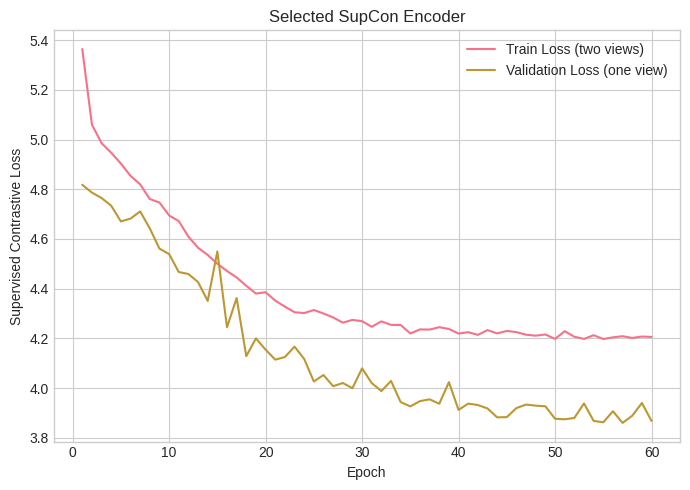

In [41]:
if CONTRASTIVE_MODEL_PATH.exists() and not RETRAIN_CONTRASTIVE:
    contrastive_checkpoint = torch.load(
        CONTRASTIVE_MODEL_PATH,
        map_location=device,
        weights_only=False,
    )
    best_contrastive_config = contrastive_checkpoint['config']
    contrastive_search_results = pd.DataFrame(contrastive_checkpoint['search_results'])
    contrastive_metrics = contrastive_checkpoint['metrics']
    best_encoder = AlzheimerContrastiveEncoder(
        backbone=best_contrastive_config['backbone'],
        projection_units=best_contrastive_config['projection_units'],
        projection_dimensions=best_contrastive_config['projection_dimensions'],
        initialize_from_imagenet=False,
    ).to(device)
    best_encoder.load_state_dict(contrastive_checkpoint['model_state_dict'])
    print(f'Loaded selected encoder from {CONTRASTIVE_MODEL_PATH}')
else:
    search_rows = []
    best_encoder_state = None
    best_contrastive_config = None
    contrastive_metrics = None
    best_search_score = (-1.0, float('-inf'))
    completed_trials = set()

    if CONTRASTIVE_SEARCH_STATE_PATH.exists():
        search_state = torch.load(
            CONTRASTIVE_SEARCH_STATE_PATH,
            map_location='cpu',
            weights_only=False,
        )
        if search_state['search_configs'] != CONTRASTIVE_SEARCH_CONFIGS:
            raise ValueError(
                'The saved contrastive search uses different configurations. '
                'Remove the search-state file or restore the original configuration list.'
            )
        search_rows = search_state['search_rows']
        completed_trials = set(search_state['completed_trials'])
        best_encoder_state = search_state['best_encoder_state']
        best_contrastive_config = search_state['best_contrastive_config']
        contrastive_metrics = search_state['metrics']
        best_search_score = tuple(search_state['best_search_score'])
        print(
            f'Resuming contrastive search with {len(completed_trials)} of '
            f'{len(CONTRASTIVE_SEARCH_CONFIGS)} trials complete.'
        )

    search_progress = tqdm(
        range(1, len(CONTRASTIVE_SEARCH_CONFIGS) + 1),
        desc='Temperature search',
    )
    for trial_number in search_progress:
        if trial_number in completed_trials:
            continue

        config = CONTRASTIVE_SEARCH_CONFIGS[trial_number - 1]
        set_seed()
        balanced_sampler.generator.manual_seed(RANDOM_STATE)
        contrastive_generator.manual_seed(RANDOM_STATE)
        trial_encoder = AlzheimerContrastiveEncoder(
            backbone=config['backbone'],
            projection_units=config['projection_units'],
            projection_dimensions=config['projection_dimensions'],
            initialize_from_imagenet=True,
        ).to(device)
        trial_optimizer = build_contrastive_optimizer(trial_encoder, config)
        trial_name = (
            f'SupCon trial {trial_number}/{len(CONTRASTIVE_SEARCH_CONFIGS)} | '
            f"{config['backbone']} tau={config['temperature']:g} "
            f"lr={config['learning_rate']:g}"
        )

        started_at = time.perf_counter()
        trial_metrics, selection = pretrain_encoder(
            trial_encoder,
            SupervisedContrastiveLoss(config['temperature']),
            trial_optimizer,
            CONTRASTIVE_SEARCH_EPOCHS,
            contrastive_train_loader,
            contrastive_validation_loader,
            patience=CONTRASTIVE_SEARCH_PATIENCE,
            model_name=trial_name,
            use_amp=USE_AMP,
        )
        training_seconds = time.perf_counter() - started_at

        train_features, train_targets = extract_representations(
            trial_encoder, original_train_loader, use_amp=USE_AMP
        )
        val_features, val_targets = extract_representations(
            trial_encoder, validation_loader, use_amp=USE_AMP
        )
        probe = train_linear_probe(
            train_features,
            train_targets,
            val_features,
            val_targets,
            CONTRASTIVE_PROBE_EPOCHS,
            CONTRASTIVE_PROBE_LEARNING_RATE,
        )

        search_rows.append({
            'Trial': trial_number,
            'Backbone': config['backbone'],
            'Temperature': config['temperature'],
            'Batch Size': contrastive_train_loader.batch_size,
            'Learning Rate': config['learning_rate'],
            'Best Epoch': selection['best_epoch'],
            'Validation Contrastive Loss': selection['val_loss'],
            'Probe Macro F1': probe['macro_f1'],
            'Probe Accuracy': probe['accuracy'],
            'Training Seconds': training_seconds,
        })

        trial_score = (probe['macro_f1'], probe['accuracy'])
        if trial_score > best_search_score:
            best_search_score = trial_score
            best_encoder_state = state_dict_to_cpu(trial_encoder)
            best_contrastive_config = copy.deepcopy(config)
            contrastive_metrics = copy.deepcopy(trial_metrics)

        completed_trials.add(trial_number)
        search_state = {
            'search_rows': search_rows,
            'completed_trials': sorted(completed_trials),
            'best_encoder_state': best_encoder_state,
            'best_contrastive_config': best_contrastive_config,
            'metrics': contrastive_metrics,
            'best_search_score': best_search_score,
            'search_configs': CONTRASTIVE_SEARCH_CONFIGS,
            'random_state': RANDOM_STATE,
        }
        temporary_search_path = CONTRASTIVE_SEARCH_STATE_PATH.with_suffix('.tmp')
        torch.save(search_state, temporary_search_path)
        temporary_search_path.replace(CONTRASTIVE_SEARCH_STATE_PATH)
        search_progress.set_postfix({
            'completed': f'{len(completed_trials)}/{len(CONTRASTIVE_SEARCH_CONFIGS)}',
            'best_f1': f'{best_search_score[0]:.4f}',
        })

        trial_encoder.cpu()
        del trial_encoder, trial_optimizer, train_features, val_features
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    contrastive_search_results = pd.DataFrame(search_rows).sort_values(
        ['Probe Macro F1', 'Probe Accuracy'],
        ascending=[False, False],
    ).reset_index(drop=True)

    best_encoder = AlzheimerContrastiveEncoder(
        backbone=best_contrastive_config['backbone'],
        projection_units=best_contrastive_config['projection_units'],
        projection_dimensions=best_contrastive_config['projection_dimensions'],
        initialize_from_imagenet=False,
    ).to(device)
    best_encoder.load_state_dict(best_encoder_state)

    final_checkpoint = {
        'model_state_dict': best_encoder_state,
        'config': best_contrastive_config,
        'search_results': contrastive_search_results.to_dict('records'),
        'metrics': contrastive_metrics,
        'class_names': CLASS_NAMES,
        'train_mean': float(TRAIN_MEAN),
        'train_std': float(TRAIN_STD),
        'random_state': RANDOM_STATE,
        'data_split': 'original_kaggle_test',
        'selection_metric': 'validation_linear_probe_macro_f1',
        'imagenet_pretrained': True,
        'input_channels': 1,
        'input_size': (128, 128),
        'mixed_precision': USE_AMP,
        'batch_size': contrastive_train_loader.batch_size,
        'balanced_sampling_power': BALANCED_SAMPLING_POWER,
    }
    temporary_model_path = CONTRASTIVE_MODEL_PATH.with_suffix('.tmp')
    torch.save(final_checkpoint, temporary_model_path)
    temporary_model_path.replace(CONTRASTIVE_MODEL_PATH)
    CONTRASTIVE_SEARCH_STATE_PATH.unlink(missing_ok=True)
    print(f'Saved selected encoder to {CONTRASTIVE_MODEL_PATH}')

display(contrastive_search_results.round(4))
print('Selected configuration:')
display(pd.Series(best_contrastive_config))
plot_contrastive_metrics(contrastive_metrics, title='Selected SupCon Encoder')

## 19. Classification from the Contrastive Encoder

The selected encoder is transferred into the same `AlzheimerResNet50` used earlier, so the classifier that sits on top of it is identical to the cross-entropy model in architecture, head size, dropout, optimizer, augmented training data and early-stopping rule. Only the starting weights of the backbone differ: supervised contrastive pretraining instead of ImageNet alone. That keeps the comparison to a single variable.

Two variants are trained. The frozen variant updates the head only and measures how much the pretrained representation already separates the classes. Its backbone weights are held fixed, but the batch-normalization statistics inside the backbone continue to track the training data, because those are buffers rather than parameters and the shared training loop keeps the model in training mode. The variant is therefore close to, but not exactly, an evaluation of the pretrained representation in isolation. The fine-tuned variant updates everything and is the one directly comparable to the earlier ResNet-50 result; it reuses that model's optimizer settings so the two differ only in where the backbone weights came from.

The temperature search settled on 0.2, but the four temperatures trained at the lower learning rate differ by two misclassified validation images out of 1,025, which is noise rather than a preference. The learning rate separated the runs far more clearly than the temperature did. The validation linear probe reached 99.5 per cent, so it can no longer distinguish between good encoders, and the test set is the only remaining source of information. It is used once per variant, after both were selected on validation alone.

In [42]:
CONTRASTIVE_CLASSIFIER_EPOCHS = 60
CONTRASTIVE_CLASSIFIER_PATIENCE = 10
RETRAIN_CONTRASTIVE_CLASSIFIER = False

FROZEN_CLASSIFIER_FILENAME = 'alzheimer_supcon_frozen.pt'
FINETUNED_CLASSIFIER_FILENAME = 'alzheimer_supcon_finetuned.pt'


def resolve_classifier_path(filename):
    local_path = MODEL_DIR / filename
    persistent_path = CONTRASTIVE_TRAINING_DIR / filename
    if not RETRAIN_CONTRASTIVE_CLASSIFIER and local_path.exists():
        return local_path
    if not RETRAIN_CONTRASTIVE_CLASSIFIER and persistent_path.exists():
        return persistent_path
    return persistent_path


FROZEN_CLASSIFIER_PATH = resolve_classifier_path(FROZEN_CLASSIFIER_FILENAME)
FINETUNED_CLASSIFIER_PATH = resolve_classifier_path(FINETUNED_CLASSIFIER_FILENAME)


def build_contrastive_classifier(encoder, freeze_backbone):
    set_seed()
    classifier = AlzheimerResNet50(
        number_of_classes=len(CLASS_NAMES),
        hidden_units=best_resnet_config['hidden_units'],
        dropout_rate=best_resnet_config.get('dropout_rate', RESNET_DROPOUT_RATE),
        initialize_from_imagenet=False,
    )

    backbone_state = {
        name: parameter
        for name, parameter in encoder.resnet.state_dict().items()
        if not name.startswith('fc.')
    }
    missing, unexpected = classifier.resnet.load_state_dict(backbone_state, strict=False)
    if unexpected:
        raise ValueError(f'Encoder holds parameters the classifier does not: {unexpected}')
    uncovered = [name for name in missing if not name.startswith('fc.')]
    if uncovered:
        raise ValueError(f'Encoder did not supply: {uncovered}')

    if freeze_backbone:
        for name, parameter in classifier.resnet.named_parameters():
            parameter.requires_grad = name.startswith('fc.')

    return classifier.to(device)


def train_contrastive_classifier(freeze_backbone, model_path, model_name):
    classifier = build_contrastive_classifier(best_encoder, freeze_backbone)

    if model_path.exists() and not RETRAIN_CONTRASTIVE_CLASSIFIER:
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)
        classifier.load_state_dict(checkpoint['model_state_dict'])
        print(f'Loaded {model_name} from {model_path}')
        return classifier, checkpoint['metrics']

    set_seed()
    augmented_generator.manual_seed(RANDOM_STATE)
    classifier_optimizer = optim.Adam(
        [parameter for parameter in classifier.parameters() if parameter.requires_grad],
        lr=best_resnet_config['learning_rate'],
        betas=best_resnet_config['betas'],
    )
    metrics, _ = train_model(
        classifier,
        criterion,
        classifier_optimizer,
        CONTRASTIVE_CLASSIFIER_EPOCHS,
        augmented_train_loader,
        validation_loader,
        patience=CONTRASTIVE_CLASSIFIER_PATIENCE,
        model_name=model_name,
        selection_metric='val_macro_f1',
        use_amp=USE_AMP,
    )
    torch.save(
        {
            'model_state_dict': classifier.state_dict(),
            'metrics': metrics,
            'class_names': CLASS_NAMES,
            'train_mean': float(TRAIN_MEAN),
            'train_std': float(TRAIN_STD),
            'random_state': RANDOM_STATE,
            'data_split': 'original_kaggle_test',
            'encoder_config': best_contrastive_config,
            'classifier_config': best_resnet_config,
            'frozen_backbone': freeze_backbone,
        },
        model_path.with_suffix('.tmp')
    )
    model_path.with_suffix('.tmp').replace(model_path)
    print(f'Saved {model_name} to {model_path}')
    return classifier, metrics


print(f'Epochs: {CONTRASTIVE_CLASSIFIER_EPOCHS}')
print(f'Early-stopping patience: {CONTRASTIVE_CLASSIFIER_PATIENCE}')
print(f'Retrain existing classifiers: {RETRAIN_CONTRASTIVE_CLASSIFIER}')
print(f"Classifier optimizer: Adam lr={best_resnet_config['learning_rate']:g} "
      f"betas={best_resnet_config['betas']}")
print(f'Frozen model path: {FROZEN_CLASSIFIER_PATH}')
print(f'Fine-tuned model path: {FINETUNED_CLASSIFIER_PATH}')

Epochs: 60
Early-stopping patience: 10
Retrain existing classifiers: False
Classifier optimizer: Adam lr=0.000225 betas=(0.963, 0.9997)
Frozen model path: /content/drive/MyDrive/alzheimer-classification/models/alzheimer_supcon_frozen.pt
Fine-tuned model path: /content/drive/MyDrive/alzheimer-classification/models/alzheimer_supcon_finetuned.pt


Loaded SupCon Frozen from /content/drive/MyDrive/alzheimer-classification/models/alzheimer_supcon_frozen.pt
Trainable parameters: 1115268 of 24617028


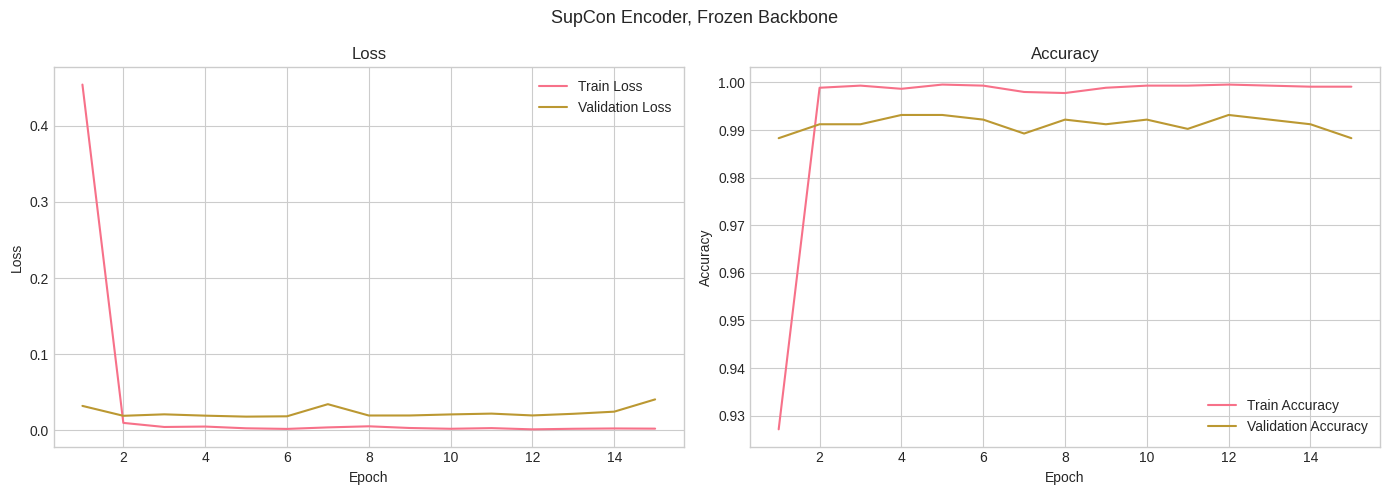

In [43]:
frozen_classifier, frozen_metrics = train_contrastive_classifier(
    freeze_backbone=True,
    model_path=FROZEN_CLASSIFIER_PATH,
    model_name='SupCon Frozen',
)

trainable = sum(
    parameter.numel()
    for parameter in frozen_classifier.parameters()
    if parameter.requires_grad
)
total = sum(parameter.numel() for parameter in frozen_classifier.parameters())
print(f'Trainable parameters: {trainable} of {total}')

plot_training_metrics(frozen_metrics, title='SupCon Encoder, Frozen Backbone')

Loaded SupCon Fine-Tuned from /content/drive/MyDrive/alzheimer-classification/models/alzheimer_supcon_finetuned.pt


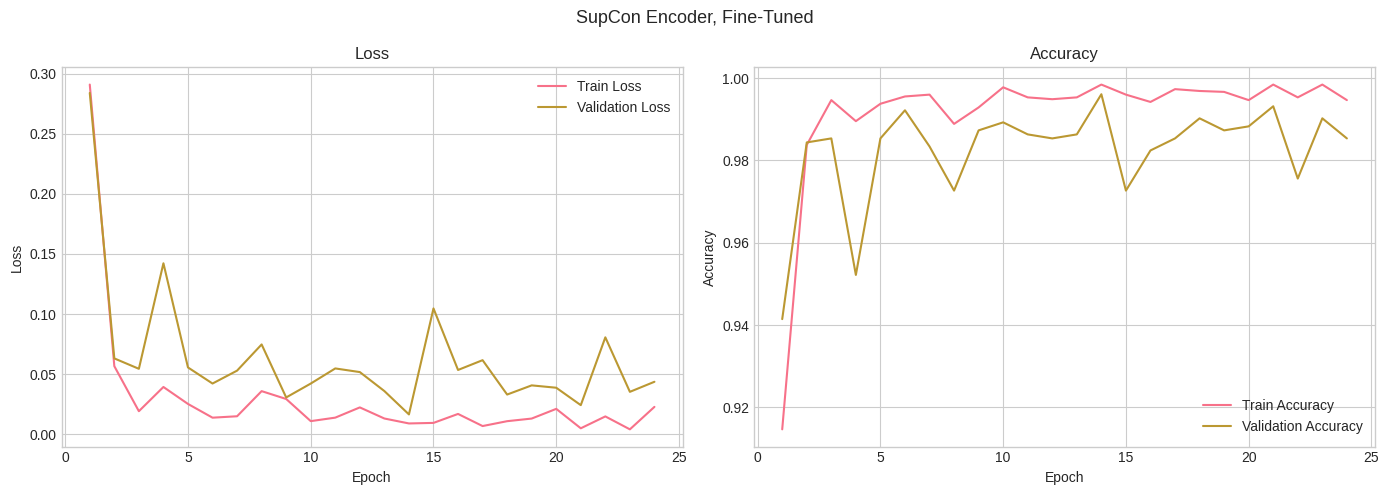

In [44]:
finetuned_classifier, finetuned_metrics = train_contrastive_classifier(
    freeze_backbone=False,
    model_path=FINETUNED_CLASSIFIER_PATH,
    model_name='SupCon Fine-Tuned',
)
plot_training_metrics(finetuned_metrics, title='SupCon Encoder, Fine-Tuned')

SupCon Frozen
Loss     : 1.1086
Accuracy : 0.7850
Weighted Precision: 0.8135
Weighted Recall   : 0.7850
Weighted F1       : 0.7789
Macro F1          : 0.7249


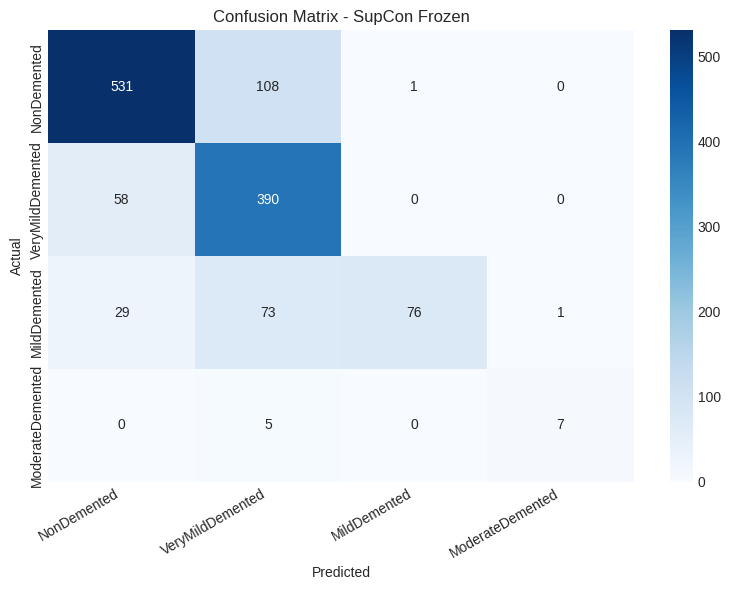

SupCon Fine-Tuned
Loss     : 0.9546
Accuracy : 0.7764
Weighted Precision: 0.7965
Weighted Recall   : 0.7764
Weighted F1       : 0.7765
Macro F1          : 0.7340


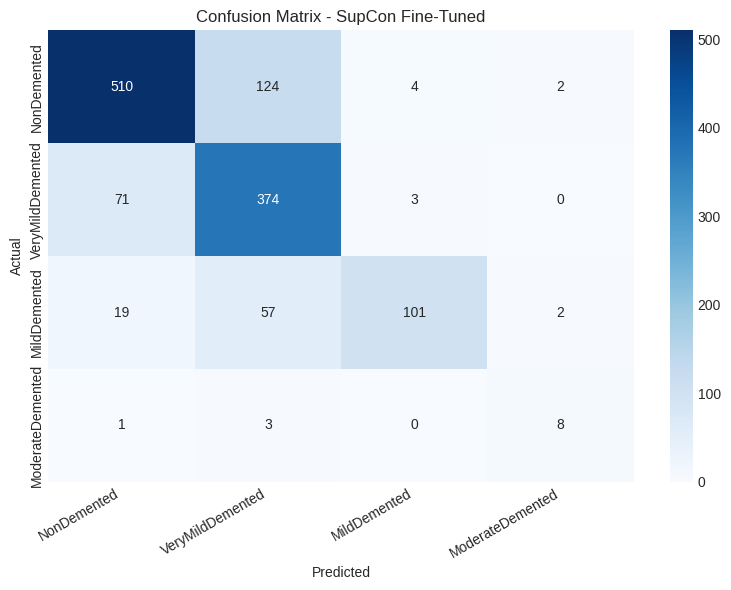

In [45]:
frozen_results = evaluate_model(
    frozen_classifier,
    criterion,
    test_loader,
    title='SupCon Frozen',
)

finetuned_results = evaluate_model(
    finetuned_classifier,
    criterion,
    test_loader,
    title='SupCon Fine-Tuned',
)

## 20. Test Comparison Including the Contrastive Models

The five models trained so far are evaluated on the same untouched Kaggle test directory with the same function, so the table below is directly comparable throughout. It is not a closing summary; the encoder has only been trained as a ResNet-50 at one batch size, and the per-class numbers below are what decide whether the remaining variants are worth running.

Each per-class score is listed with the number of test images behind it, because ModerateDemented contributes twelve of the 1,279 and its column moves by eight points whenever a single image changes side.

The contrastive models are more accurate than the cross-entropy ResNet-50 but score lower on macro F1. Those two statements are only compatible if the gain sits in the frequent classes and the loss sits in the rare ones, because accuracy counts every image once while macro F1 counts every class once. The per-class breakdown that follows separates the two effects: per-class recall shows which classes are being missed, and per-class F1 decomposes the macro score directly, since macro F1 is its unweighted mean.

This matters for the question the project set out to ask. Supervised contrastive learning was applied here with a class-balanced sampler precisely so the rare stages would be represented in every batch, and the referenced project reported a contrastive model that scored well overall while failing on the moderate class entirely. Whether the same pattern appears here is visible in the last two tables.

,Test Loss,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1
Model,,,,,,
Non-Augmented CNN,1.4658,0.6857,0.7020,0.6857,0.6718,0.4929
Augmented CNN,1.3802,0.6458,0.6782,0.6458,0.6556,0.5678
Selected ResNet-50,1.1697,0.7686,0.7743,0.7686,0.7698,0.7916
SupCon Frozen,1.1086,0.7850,0.8135,0.7850,0.7789,0.7249
SupCon Fine-Tuned,0.9546,0.7764,0.7965,0.7764,0.7765,0.7340


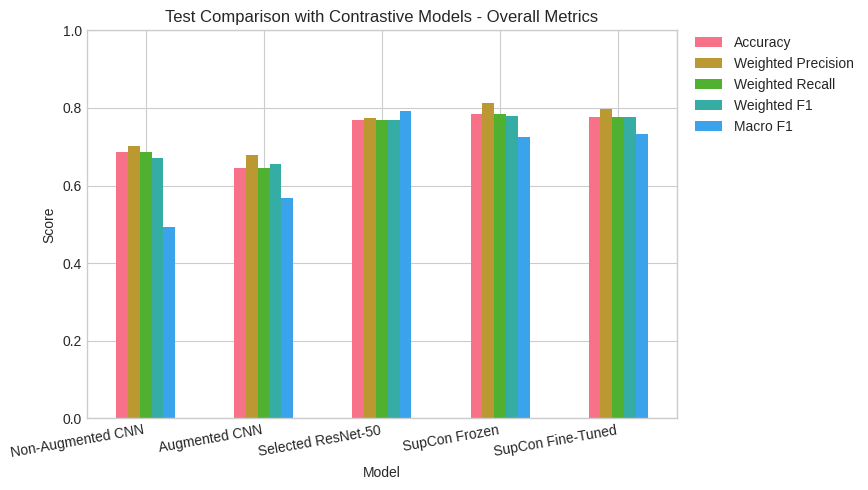

Per-Class Test Recall


,Non-Augmented CNN,Augmented CNN,Selected ResNet-50,SupCon Frozen,SupCon Fine-Tuned
Class,,,,,
NonDemented,0.7797,0.6734,0.8000,0.8297,0.7969
VeryMildDemented,0.7344,0.6228,0.7768,0.8705,0.8348
MildDemented,0.2682,0.5866,0.6257,0.4246,0.5642
ModerateDemented,0.0833,0.9167,0.9167,0.5833,0.6667


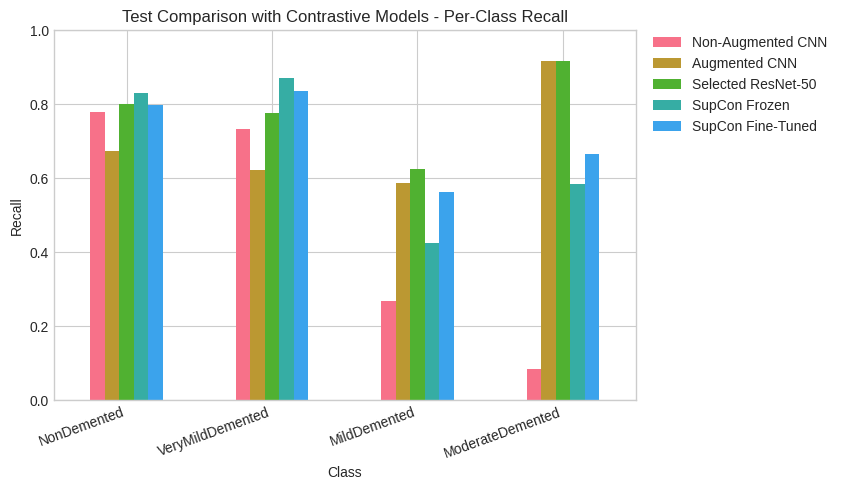

Per-Class Test F1


,Non-Augmented CNN,Augmented CNN,Selected ResNet-50,SupCon Frozen,SupCon Fine-Tuned,Test Images
Class,,,,,,
NonDemented,0.7748,0.7361,0.8271,0.8442,0.8219,640
VeryMildDemented,0.6496,0.6072,0.7296,0.7617,0.7435,448
MildDemented,0.3934,0.5048,0.6531,0.5938,0.7038,179
ModerateDemented,0.1538,0.4231,0.9565,0.7000,0.6667,12


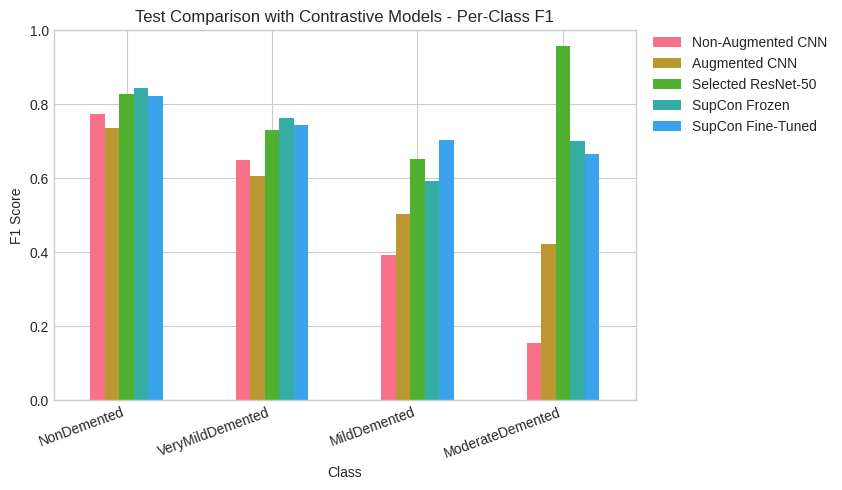

In [46]:
combined_model_results = {
    'Non-Augmented CNN': original_results,
    'Augmented CNN': augmented_results,
    'Selected ResNet-50': resnet_results,
    'SupCon Frozen': frozen_results,
    'SupCon Fine-Tuned': finetuned_results,
}

combined_comparison, combined_per_class_recall = compare_model_results(
    combined_model_results,
    title='Test Comparison with Contrastive Models',
)

combined_per_class_f1 = pd.DataFrame({
    model_name: results['per_class_f1']
    for model_name, results in combined_model_results.items()
})
combined_per_class_f1.index.name = 'Class'

per_class_f1_table = combined_per_class_f1.copy()
per_class_f1_table['Test Images'] = pd.Series(finetuned_results['support'])
print('Per-Class Test F1')
display(per_class_f1_table.round(4))

combined_per_class_f1.plot(kind='bar', figsize=(11, 5), ylim=(0, 1))
plt.title('Test Comparison with Contrastive Models - Per-Class F1')
plt.xlabel('Class')
plt.ylabel('F1 Score')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=(0, 0, 0.78, 1))
plt.show()